# Experiments 7–10: Gemma-3-27B Reference + NLA Interpretability

| Field | Value |
|---|---|
| **Author** | Elad Moshe |
| **Supervisors** | Prof. Luciano Dyballa & Prof. Andrea Cremaschi |
| **Institution** | IE Madrid — MSc Computer Science |
| **Date** | June 2026 |
| **Priority** | MUST-HAVE (all four experiments) |
| **Environment** | Local CPU — no GPU required |


> **AI Assistance Disclaimer:** Code scaffolding, documentation, and structural outlines in this notebook were generated with Claude (Anthropic). All experimental design, hypothesis framing, and interpretation are the original work of the author. AI-generated code has been reviewed and validated before execution.


## Notebook Overview

This notebook implements **Experiments 7–10** from the Final Experiment Layout. All four experiments use the **same 400 GSM8K problems** (seed=42) as Experiments 1–6, and interact with **Gemma-3-27B-IT** via the **Neuronpedia NLA API** (no local GPU needed — inference runs server-side).

| Exp | Name | API calls | Est. time | Batched? |
|---|---|---|---|---|
| **7** | Gemma-3-27B Accuracy Reference | ~800 completion calls | ~1–2 h | Yes — 4 batches × 100 per condition |
| **8** | NLA Qualitative Examples | ~10 explain calls | ~5 min | Yes — 2 cells (correct / incorrect) |
| **9** | NLA Embedding LR | ~100 explain calls | ~50 min | Yes — 10 batches × 10 |
| **10** | LLM Reads NLA | ~100 Claude calls | ~5 min | No — single cell |

### Checkpoint / resume strategy

Each batch cell saves a **per-problem checkpoint** after every API call and a **batch parquet/JSON file** when the batch completes. On kernel restart:
- Re-running a **completed** batch cell prints `[SKIP]` and exits immediately.
- Re-running a **partial** batch cell resumes from the last saved checkpoint.
- The **merge cell** (at the end of each section) is safe to re-run at any time.


## Table of Contents

0. [Setup & Constants](#0-setup--constants)
1. [API Keys](#1-api-keys)
2. [Load Dataset](#2-load-dataset)
3. [NLA Source Discovery](#3-nla-source-discovery)
4. [Experiment 7 — Gemma-3-27B Accuracy Reference](#experiment-7)
5. [Experiment 8 — NLA Qualitative Examples](#experiment-8)
6. [Experiment 9 — NLA Embedding Logistic Regression](#experiment-9)
7. [Experiment 10 — LLM Reads NLA → Predicts Correctness](#experiment-10)
8. [Final Summary](#final-summary)


## 0 — Setup & Constants


In [ ]:
import subprocess, sys
subprocess.run([
    sys.executable, '-m', 'pip', 'install', '-q',
    'requests', 'pandas', 'numpy', 'matplotlib', 'seaborn',
    'scikit-learn', 'scipy', 'tqdm', 'pyarrow', 'datasets',
    'sentence-transformers', 'anthropic',
], check=False)
print('Dependencies ready.')


Dependencies ready.


In [1]:
import os, re, json, time, warnings, getpass
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as scipy_stats
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve
from tqdm.auto import tqdm
import anthropic

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'figure.facecolor': 'white'})
print('Imports OK')


Imports OK


In [ ]:
SEED     = 42
N_SAMPLE = 400      # same 400 GSM8K problems as exp1-6
N_NLA    = 100       # 50 correct + 50 incorrect for Exp 8/9/10
N_QUALI  = 5        # qualitative examples per class for Exp 8
CV_FOLDS = 5
LR_C     = 0.1

NLA_BASE         = 'https://www.neuronpedia.org'
COMPLETION_SLEEP = 5     # seconds between completion calls
EXPLAIN_SLEEP    = 30    # seconds between explain calls (~120 req/hour)
COT_MAX_TOKENS   = 400
NOCOT_MAX_TOKENS = 100

np.random.seed(SEED)
print(f'Constants ready  SEED={SEED}  N_SAMPLE={N_SAMPLE}  N_NLA={N_NLA}')


Constants ready  SEED=42  N_SAMPLE=400  N_NLA=100


In [3]:
NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR / 'backup').exists():
    _c = NOTEBOOK_DIR / 'experiments' / 'exp7_gemma3_reference_with_NLA'
    if _c.exists():
        NOTEBOOK_DIR = _c

BACKUP_DIR  = NOTEBOOK_DIR / 'backup'
CACHE_DIR   = BACKUP_DIR / 'cache'
FIGURES_DIR = BACKUP_DIR / 'figures'
CACHE_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

_exp1_candidates = [
    NOTEBOOK_DIR.parent / 'exp1_residual_stream_regression' / 'backup' / 'cache',
    NOTEBOOK_DIR.parent.parent / 'experiments' / 'exp1_residual_stream_regression' / 'backup' / 'cache',
]
EXP1_CACHE = next((p for p in _exp1_candidates if p.exists()), None)

print(f'Notebook dir : {NOTEBOOK_DIR}')
print(f'Cache dir    : {CACHE_DIR}')
print(f'Figures dir  : {FIGURES_DIR}')
print(f'Exp1 cache   : {EXP1_CACHE}')


Notebook dir : c:\Users\97254\OneDrive\מסמכים\Elad\MSc Computer Science IE Madrid\term 3\research capstone\experiments\exp7_gemma3_reference_with_NLA
Cache dir    : c:\Users\97254\OneDrive\מסמכים\Elad\MSc Computer Science IE Madrid\term 3\research capstone\experiments\exp7_gemma3_reference_with_NLA\backup\cache
Figures dir  : c:\Users\97254\OneDrive\מסמכים\Elad\MSc Computer Science IE Madrid\term 3\research capstone\experiments\exp7_gemma3_reference_with_NLA\backup\figures
Exp1 cache   : None


## 1 — API Keys


In [4]:
NEURONPEDIA_KEY = (
    os.environ.get('NEURONPEDIA_API_KEY', '').strip()
    or getpass.getpass('Neuronpedia API key: ').strip()
)
NLA_HEADERS = {'Content-Type': 'application/json', 'x-api-key': NEURONPEDIA_KEY}
print(f'Neuronpedia key set (length={len(NEURONPEDIA_KEY)})')


Neuronpedia key set (length=50)


In [5]:
ANTHROPIC_KEY = (
    os.environ.get('ANTHROPIC_API_KEY', '').strip()
    or getpass.getpass('Anthropic API key: ').strip()
)
anthropic_client = anthropic.Anthropic(api_key=ANTHROPIC_KEY)
print('Anthropic client ready.')


Anthropic client ready.


## 2 — Load Dataset


In [6]:
_candidates = []
if EXP1_CACHE:
    _candidates.append(EXP1_CACHE / 'gsm8k_sample_400.parquet')
_candidates += [CACHE_DIR / 'gsm8k_sample_400.parquet',
                CACHE_DIR / 'gsm8k_sample_200.parquet']

_sample_path = next((p for p in _candidates if p.exists()), None)

if _sample_path:
    df_sample = pd.read_parquet(_sample_path)
    print(f'Loaded {len(df_sample)} problems from {_sample_path.name}')
    # If the file is too small, discard and re-download the full set
    if len(df_sample) < N_SAMPLE:
        print(f'WARNING: only {len(df_sample)} rows — need {N_SAMPLE}. Re-downloading from HuggingFace...')
        df_sample = None
else:
    df_sample = None

if df_sample is None:
    from datasets import load_dataset
    ds   = load_dataset('openai/gsm8k', 'main', split='test')
    rng  = np.random.default_rng(SEED)
    idxs = sorted(rng.choice(len(ds), size=N_SAMPLE, replace=False).tolist())
    df_sample = pd.DataFrame([{
        'gsm8k_idx': i, 'row_id': n,
        'problem':   ds[i]['question'],
        'gold_answer': ds[i]['answer'].split('####')[-1].strip(),
    } for n, i in enumerate(idxs)])
    _sp = CACHE_DIR / 'gsm8k_sample_400.parquet'
    df_sample.to_parquet(_sp, index=False)
    print(f'Downloaded and saved {len(df_sample)} problems to {_sp.name}')

if 'problem' not in df_sample.columns and 'question' in df_sample.columns:
    df_sample = df_sample.rename(columns={'question': 'problem'})
if 'gold_answer' not in df_sample.columns and 'answer' in df_sample.columns:
    df_sample['gold_answer'] = df_sample['answer'].str.split('####').str[-1].str.strip()

df_sample = df_sample.head(N_SAMPLE).reset_index(drop=True)
print(f'Total problems ready: {len(df_sample)}')
print(df_sample[['problem', 'gold_answer']].head(2).to_string(index=False))


Loaded 400 problems from gsm8k_sample_400.parquet
Total problems ready: 400
                                                                                                                                                                                                                                                                                        problem gold_answer
                                                                                                    Toulouse has twice as many sheep as Charleston. Charleston has 4 times as many sheep as Seattle. How many sheep do Toulouse, Charleston, and Seattle have together if Seattle has 20 sheep?         260
Carla is downloading a 200 GB file. Normally she can download 2 GB/minute, but 40% of the way through the download, Windows forces a restart to install updates, which takes 20 minutes. Then Carla has to restart the download from the beginning. How load does it take to download the file?         160


In [7]:
GEMMA2_REF = {'cot_accuracy': 0.510, 'nocot_accuracy': 0.080,
               'cot_n_correct': 204, 'nocot_n_correct': 32}
if EXP1_CACHE:
    for _fname, _cond in [('responses_cot.parquet','cot'),('responses_nocot.parquet','nocot')]:
        _p = EXP1_CACHE / _fname
        if _p.exists():
            _df = pd.read_parquet(_p)
            if 'correct' in _df.columns:
                GEMMA2_REF[f'{_cond}_accuracy']  = float(_df['correct'].mean())
                GEMMA2_REF[f'{_cond}_n_correct'] = int(_df['correct'].sum())
                print(f'Loaded Gemma-2-2B {_cond}: {GEMMA2_REF[f"{_cond}_accuracy"]:.1%}')
print(f"Gemma-2-2B ref: CoT={GEMMA2_REF['cot_accuracy']:.1%}  NoCoT={GEMMA2_REF['nocot_accuracy']:.1%}")


Gemma-2-2B ref: CoT=51.0%  NoCoT=8.0%


## 3 — NLA Source Discovery


In [8]:
_src = requests.get(f'{NLA_BASE}/api/nla/sources', headers=NLA_HEADERS, timeout=30)
_src.raise_for_status()
NLA_SOURCES = _src.json().get('sources', [])

print('Available NLA models:')
for s in NLA_SOURCES:
    print(f"  {s['modelId']:40s}  id={s['id']}")

_g3 = [s for s in NLA_SOURCES
       if 'gemma' in s['modelId'].lower() and '27b' in s['modelId'].lower()]
if not _g3:
    print('WARNING: gemma-27b not found — using first source')
    _g3 = NLA_SOURCES
NLA_MODEL_ID  = _g3[0]['modelId']
NLA_SOURCE_ID = _g3[0]['id']
print(f'Selected: {NLA_MODEL_ID}  source={NLA_SOURCE_ID}')


Available NLA models:
  gemma-3-27b-it                            id=kitft-l41
  llama3.3-70b-it                           id=kitft-l53
Selected: gemma-3-27b-it  source=kitft-l41


In [23]:
# Quick NLA example — 1 problem, completion + explain (~40s total)
_ex_row = df_sample.iloc[0]
print(f'Problem: {_ex_row["problem"][:120]}...')
print(f'Gold answer: {_ex_row["gold_answer"]}')
print()

# Step 1: get completion + tokens
_ex_data   = nla_complete(make_cot_messages(_ex_row['problem']), max_tokens=300)
_ex_parsed = parse_completion_response(_ex_data)
_ex_answer = extract_answer(_ex_parsed['response_text'] or _ex_parsed['full_text'])
print(f'Model answer: {_ex_answer}  ({"CORRECT" if is_correct(_ex_answer, _ex_row["gold_answer"]) else "INCORRECT"})')
print()

# Step 2: explain at last-pre-answer position
time.sleep(5)
if _ex_parsed['tokens']:
    _ex_pos  = find_last_pre_answer_pos(_ex_parsed['tokens'])
    _ex_raw  = nla_explain(_ex_parsed['full_text'], [_ex_pos])
    _ex_desc = parse_explain_response(_ex_raw, _ex_pos)
    print(f'NLA description at last token before answer:')
    print(f'  {_ex_desc}')
    print()
    print('Raw response keys:', list(_ex_raw.keys()))
else:
    print('No tokens returned — cannot call explain.')


Problem: Toulouse has twice as many sheep as Charleston. Charleston has 4 times as many sheep as Seattle. How many sheep do Toulo...
Gold answer: 260

Model answer: 260.0  (CORRECT)

NLA description at last token before answer:
  Structured solution pattern: a math problem explaining fractions, signaling a systematic, pedagogical answer about farm animals.

The phrase "1. The llamas of Maggie:" introduces a first step or given piece of information, establishing a specific numerical problem to solve.

Final token "The llamas of Maggie:" opens a structured solution step or labeled starting point ("1. Sheep calculation:"), immediately expecting a numerical or categorical setup, likely "Maggie has 12 llamas" or "Let's start..." or "Maggie has half as many cows as goats." or "The problem states..." or "Maggie = X, and the other..." or "Calculate the number of llamas." or "Subtract the given."

Raw response keys: ['results', 'layer_index', 'prompt_length', 'cacheId']


In [37]:
# Prompt templates: same instruction text as exp1/exp3
# NLA messages API applies Gemma-3-27B-IT chat template internally
_BOX = chr(92) + 'boxed'  # produces literal oxed

def make_cot_messages(problem: str) -> list:
    return [{'role': 'user', 'content': (
        'Solve this math problem step by step. '
        f'Show your full working, then write your final answer inside {_BOX}{{}}.' + chr(10)*2 +
        f'Problem: {problem}'
    )}]

def make_nocot_messages(problem: str) -> list:
    return [{'role': 'user', 'content': (
        'Solve this math problem. '
        f'Output ONLY your final numerical answer inside {_BOX}{{}}. No working shown.' + chr(10)*2 +
        f'Problem: {problem}'
    )}]

_BOXED_RE = re.compile(r'\boxed\{([^}]*)\}')
_NUM_RE   = re.compile(r'-?\d+(?:,\d{3})*(?:\.\d+)?')

def extract_answer(text: str):
    m = _BOXED_RE.findall(text)
    if m:
        raw = m[-1].strip().replace(',', '').replace('$', '').strip()
        try:    return float(raw)
        except: return raw
    nums = _NUM_RE.findall(text.replace(',', '').replace('$', ''))
    return float(nums[-1]) if nums else None

def is_correct(pred, gold: str) -> bool:
    if pred is None: return False
    def _clean(s): return str(s).strip().replace(',', '').replace('$', '').replace('%', '').strip()
    try:    return abs(float(_clean(pred)) - float(_clean(gold))) < 1e-3
    except: return _clean(pred) == _clean(gold)

print('Prompt helpers ready. Answer extraction handles $, commas, % symbols.')
# Quick sanity check
assert is_correct('$75.00', '75'),  'dollar sign fix broken'
assert is_correct('9.0',    '9'),   'float/int fix broken'
assert is_correct('$90',    '90'),  'dollar sign fix broken'
print('is_correct sanity checks passed.')


Prompt helpers ready. Answer extraction handles $, commas, % symbols.
is_correct sanity checks passed.


In [22]:
def nla_complete(messages, max_tokens=300, temperature=0.0, retries=3):
    payload = {'modelId': NLA_MODEL_ID, 'nlaSourceId': NLA_SOURCE_ID,
                'messages': messages, 'completion_tokens': max_tokens, 'temperature': temperature}
    for attempt in range(retries):
        try:
            r = requests.post(f'{NLA_BASE}/api/nla/completion',
                              headers=NLA_HEADERS, json=payload, timeout=120)
            if r.status_code == 429:
                wait = int(r.headers.get('Retry-After', 60))
                print(f'  Rate limited — waiting {wait}s'); time.sleep(wait); continue
            r.raise_for_status(); return r.json()
        except Exception as e:
            if attempt == retries - 1: raise
            print(f'  Retry {attempt+1}: {e}'); time.sleep(10)
    return {}

def nla_explain(full_text, positions, temperature=0.0, retries=3):
    payload = {'modelId': NLA_MODEL_ID, 'nlaSourceId': NLA_SOURCE_ID,
                'text': full_text, 'positions': positions, 'temperature': temperature}
    for attempt in range(retries):
        try:
            r = requests.post(f'{NLA_BASE}/api/nla/explain',
                              headers=NLA_HEADERS, json=payload, timeout=120)
            if r.status_code == 429:
                wait = int(r.headers.get('Retry-After', 60))
                print(f'  Rate limited — waiting {wait}s'); time.sleep(wait); continue
            r.raise_for_status(); return r.json()
        except Exception as e:
            if attempt == retries - 1: raise
            print(f'  Retry {attempt+1}: {e}'); time.sleep(10)
    return {}

def parse_completion_response(data):
    text = (data.get('completion') or data.get('text') or
            data.get('full_text') or data.get('response') or '')
    response_text = data.get('response_text') or data.get('generated_text') or text
    return {'full_text': text, 'response_text': response_text, 'tokens': data.get('tokens', [])}

def find_last_pre_answer_pos(tokens):
    toks = sorted(tokens, key=lambda x: x.get('position', 0))
    cum = ''
    for i, t in enumerate(toks):
        cum += t.get('token', '')
        if '\\boxed{' in cum:
            return toks[i-1]['position'] if i > 0 else toks[0]['position']
    return toks[-2]['position'] if len(toks) >= 2 else toks[-1]['position']

def parse_explain_response(data, position):
    # Primary format: {"results": [{"position": N, "description": "..."}]}
    if 'results' in data:
        results = data['results']
        if isinstance(results, list) and results:
            for r in results:
                if r.get('position') == position and 'description' in r:
                    return str(r['description'])
            if 'description' in results[0]:
                return str(results[0]['description'])
    # Legacy / alternative formats
    if 'descriptions' in data:
        descs = data['descriptions']
        if isinstance(descs, list) and descs:
            for d in descs:
                if d.get('position') == position:
                    return str(d.get('description', d.get('text', '')))
            first = descs[0]
            return str(first.get('description', first.get('text', first)) if isinstance(first, dict) else first)
        if isinstance(descs, dict):
            return str(descs.get(str(position), next(iter(descs.values()), '')))
    for key in ('nla', 'explanation', 'nlaText', 'nla_text', 'description', 'text'):
        v = data.get(key)
        if isinstance(v, str) and ' ' in v and len(v) > 10:
            return v
    if str(position) in data:
        v = data[str(position)]
        return str(v.get('description', v.get('text', v)) if isinstance(v, dict) else v)
    for val in data.values():
        if isinstance(val, str) and ' ' in val and len(val) > 10:
            return val
    return '[RAW] ' + json.dumps(data)

print('NLA helper functions ready.')


NLA helper functions ready.


### Batch runner helpers (Exp 7)

The two functions below are used by the batch cells in Exp 7. Each batch cell calls one of these with its own index range.


In [16]:
def _run_cot_batch(batch_start, batch_end, batch_id):
    """Run CoT completions for df_sample[batch_start:batch_end] with checkpoint."""
    batch_file = CACHE_DIR / f'exp7_cot_batch{batch_id}.parquet'
    batch_ckpt = CACHE_DIR / f'exp7_cot_batch{batch_id}_ckpt.json'

    if batch_file.exists():
        _df = pd.read_parquet(batch_file)
        print(f'[SKIP] CoT batch {batch_id} already saved '
              f'({len(_df)} rows, acc={_df["correct"].mean():.1%})')
        return _df

    records, start_idx = [], batch_start
    if batch_ckpt.exists():
        _chk = json.loads(batch_ckpt.read_text())
        records   = _chk['records']
        start_idx = _chk['next_idx']
        print(f'Resuming CoT batch {batch_id} from idx {start_idx}')
    else:
        print(f'Starting CoT batch {batch_id} (idx {batch_start}–{batch_end-1}) '
              f'  ~{(batch_end-batch_start)*COMPLETION_SLEEP/60:.0f} min')

    for i in tqdm(range(start_idx, batch_end), desc=f'CoT b{batch_id}'):
        row = df_sample.iloc[i]
        try:
            data   = nla_complete(make_cot_messages(row['problem']),
                                  max_tokens=COT_MAX_TOKENS)
            parsed = parse_completion_response(data)
            pred   = extract_answer(parsed['response_text'] or parsed['full_text'])
            records.append({
                'row_id':        int(row.get('row_id', i)),
                'gsm8k_idx':     int(row.get('gsm8k_idx', i)),
                'problem':       row['problem'],
                'gold_answer':   row['gold_answer'],
                'response_text': parsed['response_text'],
                'pred_answer':   str(pred),
                'correct':       bool(is_correct(pred, row['gold_answer'])),
                'full_text':     parsed['full_text'],
                'tokens_json':   json.dumps(parsed['tokens']),
            })
        except Exception as e:
            print(f'  Error idx {i}: {e}')
            records.append({
                'row_id': int(row.get('row_id', i)), 'gsm8k_idx': int(row.get('gsm8k_idx', i)),
                'problem': row['problem'], 'gold_answer': row['gold_answer'],
                'response_text': '', 'pred_answer': 'None', 'correct': False,
                'full_text': '', 'tokens_json': '[]',
            })
        batch_ckpt.write_text(json.dumps({'records': records, 'next_idx': i + 1}))
        if i < batch_end - 1:
            time.sleep(COMPLETION_SLEEP)

    _df_batch = pd.DataFrame(records)
    _df_batch.to_parquet(batch_file, index=False)
    batch_ckpt.unlink(missing_ok=True)
    print(f'  Batch {batch_id} done — {len(_df_batch)} rows  acc={_df_batch["correct"].mean():.1%}')
    return _df_batch

def _run_nocot_batch(batch_start, batch_end, batch_id):
    """Run NoCoT completions for df_sample[batch_start:batch_end] with checkpoint."""
    batch_file = CACHE_DIR / f'exp7_nocot_batch{batch_id}.parquet'
    batch_ckpt = CACHE_DIR / f'exp7_nocot_batch{batch_id}_ckpt.json'

    if batch_file.exists():
        _df = pd.read_parquet(batch_file)
        print(f'[SKIP] NoCoT batch {batch_id} already saved '
              f'({len(_df)} rows, acc={_df["correct"].mean():.1%})')
        return _df

    records, start_idx = [], batch_start
    if batch_ckpt.exists():
        _chk = json.loads(batch_ckpt.read_text())
        records   = _chk['records']
        start_idx = _chk['next_idx']
        print(f'Resuming NoCoT batch {batch_id} from idx {start_idx}')
    else:
        print(f'Starting NoCoT batch {batch_id} (idx {batch_start}–{batch_end-1}) '
              f'  ~{(batch_end-batch_start)*COMPLETION_SLEEP/60:.0f} min')

    for i in tqdm(range(start_idx, batch_end), desc=f'NoCoT b{batch_id}'):
        row = df_sample.iloc[i]
        try:
            data   = nla_complete(make_nocot_messages(row['problem']),
                                  max_tokens=NOCOT_MAX_TOKENS)
            parsed = parse_completion_response(data)
            pred   = extract_answer(parsed['response_text'] or parsed['full_text'])
            records.append({
                'row_id':        int(row.get('row_id', i)),
                'gsm8k_idx':     int(row.get('gsm8k_idx', i)),
                'problem':       row['problem'],
                'gold_answer':   row['gold_answer'],
                'response_text': parsed['response_text'],
                'pred_answer':   str(pred),
                'correct':       bool(is_correct(pred, row['gold_answer'])),
                'full_text':     parsed['full_text'],
                'tokens_json':   json.dumps(parsed['tokens']),
            })
        except Exception as e:
            print(f'  Error idx {i}: {e}')
            records.append({
                'row_id': int(row.get('row_id', i)), 'gsm8k_idx': int(row.get('gsm8k_idx', i)),
                'problem': row['problem'], 'gold_answer': row['gold_answer'],
                'response_text': '', 'pred_answer': 'None', 'correct': False,
                'full_text': '', 'tokens_json': '[]',
            })
        batch_ckpt.write_text(json.dumps({'records': records, 'next_idx': i + 1}))
        if i < batch_end - 1:
            time.sleep(COMPLETION_SLEEP)

    _df_batch = pd.DataFrame(records)
    _df_batch.to_parquet(batch_file, index=False)
    batch_ckpt.unlink(missing_ok=True)
    print(f'  Batch {batch_id} done — {len(_df_batch)} rows  acc={_df_batch["correct"].mean():.1%}')
    return _df_batch

print("Batch runner helpers ready.")

Batch runner helpers ready.


---
## Experiment 7 — Gemma-3-27B Accuracy Reference
<a id="experiment-7"></a>

**Purpose:** Cross-model reference. Shows the CoT accuracy benefit for Gemma-3-27B on the same 400 GSM8K problems used in Exp 1–6.

**Batching:** 400 problems split into 4 independent batches of 100. Each batch saves to its own `.parquet` file. A final merge cell combines them.

| Batch | Problems | Est. time | Output file |
|---|---|---|---|
| 0 | 0–99 | ~8 min | `exp7_cot_batch0.parquet` |
| 1 | 100–199 | ~8 min | `exp7_cot_batch1.parquet` |
| 2 | 200–299 | ~8 min | `exp7_cot_batch2.parquet` |
| 3 | 300–399 | ~8 min | `exp7_cot_batch3.parquet` |

> **If the kernel restarts mid-batch:** re-run that batch cell — it will resume from the last saved checkpoint automatically.
> **If a batch is already complete:** re-running its cell prints `[SKIP]` instantly.


In [18]:
# Cleanup: delete any batch files produced from the wrong (200-row) dataset.
# Safe to re-run — if files don't exist it just prints 'nothing to clean'.
_cleaned = []
for _b in range(4):
    for _f in [
        CACHE_DIR / f'exp7_cot_batch{_b}.parquet',
        CACHE_DIR / f'exp7_cot_batch{_b}_ckpt.json',
        CACHE_DIR / f'exp7_nocot_batch{_b}.parquet',
        CACHE_DIR / f'exp7_nocot_batch{_b}_ckpt.json',
    ]:
        if _f.exists(): _f.unlink(); _cleaned.append(_f.name)
if _cleaned:
    print('Deleted stale batch files:')
    for _n in _cleaned: print(f'  {_n}')
else:
    print('Nothing to clean — no stale batch files found.')
assert len(df_sample) >= 400, f'df_sample only has {len(df_sample)} rows — re-run c014 first!'
print(f'OK: df_sample has {len(df_sample)} rows. Ready to run batches.')


Deleted stale batch files:
  exp7_cot_batch0.parquet
  exp7_nocot_batch0.parquet
  exp7_cot_batch1.parquet
  exp7_nocot_batch1.parquet
  exp7_cot_batch2.parquet
  exp7_cot_batch2_ckpt.json
  exp7_nocot_batch2.parquet
  exp7_cot_batch3.parquet
  exp7_nocot_batch3.parquet
OK: df_sample has 400 rows. Ready to run batches.


### Exp 7 — CoT Condition


In [19]:
# CoT batch 0 — problems 0–99  (~8 min, checkpointed per-call)
_cot_b0 = _run_cot_batch(batch_start=0, batch_end=100, batch_id=0)


Starting CoT batch 0 (idx 0–99)   ~8 min


CoT b0:   0%|          | 0/100 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [26]:
# CoT batch 1 — problems 100–199  (~16 min)
_cot_b1 = _run_cot_batch(batch_start=100, batch_end=200, batch_id=1)


Starting CoT batch 1 (idx 100–199)   ~8 min


CoT b1:   0%|          | 0/100 [00:00<?, ?it/s]

  Batch 1 done — 100 rows  acc=72.0%


In [27]:
print(len(df_sample))


400


In [28]:
# CoT batch 2 — problems 200–299  (~16 min)
_cot_b2 = _run_cot_batch(batch_start=200, batch_end=300, batch_id=2)


Starting CoT batch 2 (idx 200–299)   ~8 min


CoT b2:   0%|          | 0/100 [00:00<?, ?it/s]

  Batch 2 done — 100 rows  acc=69.0%


In [29]:
# CoT batch 3 — problems 300–399  (~16 min)
_cot_b3 = _run_cot_batch(batch_start=300, batch_end=400, batch_id=3)


Starting CoT batch 3 (idx 300–399)   ~8 min


CoT b3:   0%|          | 0/100 [00:00<?, ?it/s]

  Rate limited — waiting 60s
  Rate limited — waiting 60s
  Rate limited — waiting 60s
  Rate limited — waiting 60s
  Rate limited — waiting 60s
  Rate limited — waiting 60s
  Rate limited — waiting 60s
  Rate limited — waiting 60s
  Rate limited — waiting 60s
  Rate limited — waiting 60s
  Rate limited — waiting 60s
  Rate limited — waiting 60s
  Rate limited — waiting 60s
  Rate limited — waiting 60s
  Rate limited — waiting 60s
  Rate limited — waiting 60s
  Rate limited — waiting 60s
  Batch 3 done — 100 rows  acc=78.0%


In [30]:
# Merge CoT batches -> df_cot7
# Safe to re-run; skips if final file already exists.
COT_MERGED = CACHE_DIR / 'exp7_completions_cot.parquet'
if COT_MERGED.exists():
    df_cot7 = pd.read_parquet(COT_MERGED)
    print(f'[CACHE] Loaded merged CoT: {len(df_cot7)} rows  acc={df_cot7["correct"].mean():.1%}')
else:
    _parts = []
    for b in range(4):
        _bf = CACHE_DIR / f'exp7_cot_batch{b}.parquet'
        if not _bf.exists():
            raise FileNotFoundError(f'Batch {b} not complete — run c021{"abcd"[b]} first.')
        _parts.append(pd.read_parquet(_bf))
    df_cot7 = pd.concat(_parts, ignore_index=True)
    df_cot7.to_parquet(COT_MERGED, index=False)
    print(f'Merged {len(df_cot7)} CoT rows  acc={df_cot7["correct"].mean():.1%}')
    print(f'Saved -> {COT_MERGED.name}')


[CACHE] Loaded merged CoT: 400 rows  acc=74.2%


### Exp 7 — NoCoT Condition


In [31]:
# NoCoT batch 0 — problems 0–99  (~8 min, checkpointed per-call)
_nocot_b0 = _run_nocot_batch(batch_start=0, batch_end=100, batch_id=0)


Starting NoCoT batch 0 (idx 0–99)   ~8 min


NoCoT b0:   0%|          | 0/100 [00:00<?, ?it/s]

  Rate limited — waiting 60s
  Rate limited — waiting 60s
  Rate limited — waiting 60s
  Rate limited — waiting 60s
  Rate limited — waiting 60s
  Rate limited — waiting 60s
  Rate limited — waiting 60s
  Rate limited — waiting 60s
  Rate limited — waiting 60s
  Rate limited — waiting 60s
  Rate limited — waiting 60s
  Rate limited — waiting 60s
  Batch 0 done — 100 rows  acc=34.0%


In [32]:
# NoCoT batch 1 — problems 100–199  (~8 min)
_nocot_b1 = _run_nocot_batch(batch_start=100, batch_end=200, batch_id=1)


Starting NoCoT batch 1 (idx 100–199)   ~8 min


NoCoT b1:   0%|          | 0/100 [00:00<?, ?it/s]

  Batch 1 done — 100 rows  acc=27.0%


In [33]:
# NoCoT batch 2 — problems 200–299  (~8 min)
_nocot_b2 = _run_nocot_batch(batch_start=200, batch_end=300, batch_id=2)


Starting NoCoT batch 2 (idx 200–299)   ~8 min


NoCoT b2:   0%|          | 0/100 [00:00<?, ?it/s]

  Batch 2 done — 100 rows  acc=31.0%


In [34]:
# NoCoT batch 3 — problems 300–399  (~8 min)
_nocot_d3 = _run_nocot_batch(batch_start=300, batch_end=400, batch_id=3)


Starting NoCoT batch 3 (idx 300–399)   ~8 min


NoCoT b3:   0%|          | 0/100 [00:00<?, ?it/s]

  Retry 1: HTTPSConnectionPool(host='www.neuronpedia.org', port=443): Read timed out. (read timeout=120)
  Retry 1: ('Connection aborted.', ConnectionResetError(10054, 'An existing connection was forcibly closed by the remote host', None, 10054, None))
  Batch 3 done — 100 rows  acc=34.0%


In [38]:
# Merge NoCoT batches -> df_nocot7
NOCOT_MERGED = CACHE_DIR / 'exp7_completions_nocot.parquet'
if NOCOT_MERGED.exists():
    df_nocot7 = pd.read_parquet(NOCOT_MERGED)
    print(f'[CACHE] Loaded merged NoCoT: {len(df_nocot7)} rows  acc={df_nocot7["correct"].mean():.1%}')
else:
    _parts = []
    for b in range(4):
        _bf = CACHE_DIR / f'exp7_nocot_batch{b}.parquet'
        if not _bf.exists():
            raise FileNotFoundError(f'Batch {b} not complete — run c022{"abcd"[b]} first.')
        _parts.append(pd.read_parquet(_bf))
    df_nocot7 = pd.concat(_parts, ignore_index=True)
    df_nocot7.to_parquet(NOCOT_MERGED, index=False)
    print(f'Merged {len(df_nocot7)} NoCoT rows  acc={df_nocot7["correct"].mean():.1%}')
    print(f'Saved -> {NOCOT_MERGED.name}')


[CACHE] Loaded merged NoCoT: 400 rows  acc=31.5%


In [39]:
# Fix accuracy: re-evaluate predictions with improved answer extraction
# Handles $, commas, % that caused correct answers to be marked wrong.
# Re-saves both parquets and the accuracy table.

def _recheck(df):
    old = df['correct'].sum()
    df = df.copy()
    df['correct'] = df.apply(
        lambda r: is_correct(r['pred_answer'], r['gold_answer']), axis=1)
    new = df['correct'].sum()
    return df, int(old), int(new)

df_cot7,   _old_c, _new_c  = _recheck(df_cot7)
df_nocot7, _old_nc, _new_nc = _recheck(df_nocot7)

print(f'CoT   correct: {_old_c} -> {_new_c}  (+{_new_c - _old_c})')
print(f'NoCoT correct: {_old_nc} -> {_new_nc}  (+{_new_nc - _old_nc})')

# Re-save parquets
df_cot7.to_parquet(CACHE_DIR / 'exp7_completions_cot.parquet',   index=False)
df_nocot7.to_parquet(CACHE_DIR / 'exp7_completions_nocot.parquet', index=False)

# Save a fixed accuracy CSV
_fix_csv = CACHE_DIR / 'exp7_accuracy_fixed.csv'
_fix_table = pd.DataFrame([
    {'Model': 'Gemma-3-27B', 'Condition': 'CoT',
     'N_correct_original': _old_c,  'N_correct_fixed': _new_c,
     'Acc_original': _old_c/len(df_cot7),   'Acc_fixed': _new_c/len(df_cot7)},
    {'Model': 'Gemma-3-27B', 'Condition': 'NoCoT',
     'N_correct_original': _old_nc, 'N_correct_fixed': _new_nc,
     'Acc_original': _old_nc/len(df_nocot7), 'Acc_fixed': _new_nc/len(df_nocot7)},
])
_fix_table.to_csv(_fix_csv, index=False)
print(f'Saved fixed accuracy table -> {_fix_csv.name}')


CoT   correct: 297 -> 366  (+69)
NoCoT correct: 126 -> 126  (+0)
Saved fixed accuracy table -> exp7_accuracy_fixed.csv


### Exp 7 — Accuracy Analysis


In [40]:
g3_cot_acc   = df_cot7['correct'].mean()
g3_nocot_acc = df_nocot7['correct'].mean()
g3_cot_n     = int(df_cot7['correct'].sum())
g3_nocot_n   = int(df_nocot7['correct'].sum())
g2_cot_acc   = GEMMA2_REF['cot_accuracy']
g2_nocot_acc = GEMMA2_REF['nocot_accuracy']

print('=' * 72)
print('  EXP 7 — CROSS-MODEL ACCURACY COMPARISON (GSM8K, n=400, seed=42)')
print('=' * 72)
print(f"  {'Model':<20} {'Cond':<8} {'Accuracy':>10} {'N correct':>10} {'N total':>8}")
print('  ' + '-'*60)
for row in [
    ('Gemma-2-2B','CoT',   g2_cot_acc,   GEMMA2_REF['cot_n_correct'],   400),
    ('Gemma-2-2B','NoCoT', g2_nocot_acc, GEMMA2_REF['nocot_n_correct'], 400),
    ('Gemma-3-27B','CoT',  g3_cot_acc,   g3_cot_n,   len(df_cot7)),
    ('Gemma-3-27B','NoCoT',g3_nocot_acc, g3_nocot_n, len(df_nocot7)),
]:
    print(f'  {row[0]:<20} {row[1]:<8} {row[2]:>10.1%} {row[3]:>10} {row[4]:>8}')
print('=' * 72)
print(f'  CoT benefit (Gemma-2-2B):  {g2_cot_acc - g2_nocot_acc:+.1%}')
print(f'  CoT benefit (Gemma-3-27B): {g3_cot_acc - g3_nocot_acc:+.1%}')
print('=' * 72)

df_acc_table = pd.DataFrame([
    {'Model':'Gemma-2-2B',  'Condition':'CoT',   'Accuracy':g2_cot_acc,   'N_correct':GEMMA2_REF['cot_n_correct'],   'N_total':400},
    {'Model':'Gemma-2-2B',  'Condition':'NoCoT', 'Accuracy':g2_nocot_acc, 'N_correct':GEMMA2_REF['nocot_n_correct'], 'N_total':400},
    {'Model':'Gemma-3-27B', 'Condition':'CoT',   'Accuracy':g3_cot_acc,   'N_correct':g3_cot_n,   'N_total':len(df_cot7)},
    {'Model':'Gemma-3-27B', 'Condition':'NoCoT', 'Accuracy':g3_nocot_acc, 'N_correct':g3_nocot_n, 'N_total':len(df_nocot7)},
])
df_acc_table.to_csv(CACHE_DIR / 'exp7_accuracy_table.csv', index=False)
print('Saved accuracy table.')


  EXP 7 — CROSS-MODEL ACCURACY COMPARISON (GSM8K, n=400, seed=42)
  Model                Cond       Accuracy  N correct  N total
  ------------------------------------------------------------
  Gemma-2-2B           CoT           51.0%        204      400
  Gemma-2-2B           NoCoT          8.0%         32      400
  Gemma-3-27B          CoT           91.5%        366      400
  Gemma-3-27B          NoCoT         31.5%        126      400
  CoT benefit (Gemma-2-2B):  +43.0%
  CoT benefit (Gemma-3-27B): +60.0%
Saved accuracy table.


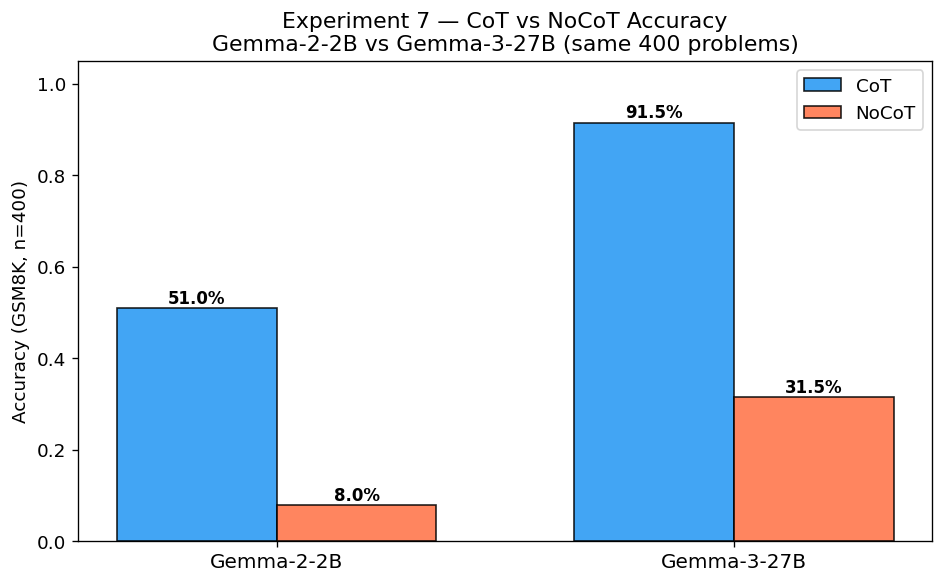

In [41]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(2); w = 0.35
b1 = ax.bar(x - w/2, [g2_cot_acc,   g3_cot_acc],   w, label='CoT',   color='#2196F3', alpha=0.85, edgecolor='black')
b2 = ax.bar(x + w/2, [g2_nocot_acc, g3_nocot_acc], w, label='NoCoT', color='#FF7043', alpha=0.85, edgecolor='black')
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.1%}', ha='center', fontsize=10, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(['Gemma-2-2B', 'Gemma-3-27B'], fontsize=12)
ax.set_ylabel('Accuracy (GSM8K, n=400)')
ax.set_title('Experiment 7 — CoT vs NoCoT Accuracy\nGemma-2-2B vs Gemma-3-27B (same 400 problems)')
ax.legend(fontsize=11); ax.set_ylim(0, 1.05)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'exp7_accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


In [47]:
# Clear stale NLA caches (Exp 8 + 9) so they re-fetch with the fixed parser.
# Safe to re-run — skips files that don't exist.
_stale = [
    'exp8_nla_correct.json', 'exp8_nla_incorrect.json',
    'exp8_nla_examples.json', 'exp8_nla_examples_table.csv',
    'exp9_nla_descriptions.json',
    'exp9_embeddings.npy', 'exp9_labels.npy', 'exp9_lr_results.json',
] + [f'exp9_nla_batch{b}.json'      for b in range(10)] \
  + [f'exp9_nla_batch{b}_ckpt.json' for b in range(10)]
_deleted = []
for _f in _stale:
    _p = CACHE_DIR / _f
    if _p.exists(): _p.unlink(); _deleted.append(_f)
if _deleted:
    print('Deleted stale NLA caches:')
    for _f in _deleted: print(f'  {_f}')
else:
    print('Nothing to delete.')
print('Re-run cells c027a-c027c (Exp 8) and c031a-c031j (Exp 9) to re-fetch.')


Deleted stale NLA caches:
  exp8_nla_correct.json
  exp8_nla_incorrect.json
  exp8_nla_examples.json
  exp8_nla_examples_table.csv
Re-run cells c027a-c027c (Exp 8) and c031a-c031j (Exp 9) to re-fetch.


---
## Experiment 8 — NLA Qualitative Examples
<a id="experiment-8"></a>

**Purpose:** Illustrate qualitative differences in NLA descriptions between correct and incorrect chains. DEMONSTRATIVE only — no statistics.

**Batching:** 5 correct examples (cell A) + 5 incorrect examples (cell B). Each cell saves its results independently. A merge cell combines them.

| Cell | Calls | Est. time | Output file |
|---|---|---|---|
| A | 5 (correct) | ~2.5 min | `exp8_nla_correct.json` |
| B | 5 (incorrect) | ~2.5 min | `exp8_nla_incorrect.json` |
| Merge | — | instant | `exp8_nla_examples.json` |


In [48]:
# Select examples — must run before the batch cells
_valid8     = df_cot7[df_cot7['full_text'].str.len() > 10].copy()
_correct8   = _valid8[_valid8['correct'] == True]
_incorrect8 = _valid8[_valid8['correct'] == False]
n_each      = min(N_QUALI, len(_correct8), len(_incorrect8))

df_quali_correct   = _correct8.sample(n=n_each,   random_state=SEED).reset_index(drop=True)
df_quali_incorrect = _incorrect8.sample(n=n_each, random_state=SEED).reset_index(drop=True)

print(f'Exp 8: {len(df_quali_correct)} correct + {len(df_quali_incorrect)} incorrect selected')


Exp 8: 5 correct + 5 incorrect selected


### Exp 8 — NLA Explain Calls

> Each cell below is independent. Re-running a completed cell prints `[SKIP]` and exits.


In [49]:
# Exp 8A — correct examples (5 explain calls, ~2.5 min)
EXP8_CORRECT_CACHE = CACHE_DIR / 'exp8_nla_correct.json'

if EXP8_CORRECT_CACHE.exists():
    exp8_correct_records = json.loads(EXP8_CORRECT_CACHE.read_text())
    print(f'[SKIP] exp8_nla_correct.json already saved ({len(exp8_correct_records)} records)')
else:
    exp8_correct_records = []
    print(f'Fetching NLA for {len(df_quali_correct)} correct examples...')
    for i, (_, row) in enumerate(df_quali_correct.iterrows()):
        tokens = json.loads(row['tokens_json']) if isinstance(row['tokens_json'], str) else []
        if not tokens:
            nla_desc = '[no tokens]'
        else:
            pos = find_last_pre_answer_pos(tokens)
            try:
                nla_desc = parse_explain_response(nla_explain(row['full_text'], [pos]), pos)
            except Exception as e:
                nla_desc = f'[error: {e}]'
            if i < len(df_quali_correct) - 1:
                time.sleep(EXPLAIN_SLEEP)
        exp8_correct_records.append({
            'row_id': int(row.get('row_id', i)), 'correct': True,
            'gold_answer': row['gold_answer'], 'pred_answer': row['pred_answer'],
            'problem': row['problem'][:200], 'response_text': row['response_text'][:300],
            'nla_description': nla_desc,
        })
    EXP8_CORRECT_CACHE.write_text(json.dumps(exp8_correct_records, indent=2))
    print(f'Saved {len(exp8_correct_records)} records -> {EXP8_CORRECT_CACHE.name}')


Fetching NLA for 5 correct examples...
Saved 5 records -> exp8_nla_correct.json


In [50]:
# Exp 8B — incorrect examples (5 explain calls, ~2.5 min)
EXP8_INCORRECT_CACHE = CACHE_DIR / 'exp8_nla_incorrect.json'

if EXP8_INCORRECT_CACHE.exists():
    exp8_incorrect_records = json.loads(EXP8_INCORRECT_CACHE.read_text())
    print(f'[SKIP] exp8_nla_incorrect.json already saved ({len(exp8_incorrect_records)} records)')
else:
    exp8_incorrect_records = []
    print(f'Fetching NLA for {len(df_quali_incorrect)} incorrect examples...')
    for i, (_, row) in enumerate(df_quali_incorrect.iterrows()):
        tokens = json.loads(row['tokens_json']) if isinstance(row['tokens_json'], str) else []
        if not tokens:
            nla_desc = '[no tokens]'
        else:
            pos = find_last_pre_answer_pos(tokens)
            try:
                nla_desc = parse_explain_response(nla_explain(row['full_text'], [pos]), pos)
            except Exception as e:
                nla_desc = f'[error: {e}]'
            if i < len(df_quali_incorrect) - 1:
                time.sleep(EXPLAIN_SLEEP)
        exp8_incorrect_records.append({
            'row_id': int(row.get('row_id', i)), 'correct': False,
            'gold_answer': row['gold_answer'], 'pred_answer': row['pred_answer'],
            'problem': row['problem'][:200], 'response_text': row['response_text'][:300],
            'nla_description': nla_desc,
        })
    EXP8_INCORRECT_CACHE.write_text(json.dumps(exp8_incorrect_records, indent=2))
    print(f'Saved {len(exp8_incorrect_records)} records -> {EXP8_INCORRECT_CACHE.name}')


Fetching NLA for 5 incorrect examples...
Saved 5 records -> exp8_nla_incorrect.json


In [51]:
# Merge Exp 8 — combine correct + incorrect -> exp8_records
EXP8_CACHE = CACHE_DIR / 'exp8_nla_examples.json'
if EXP8_CACHE.exists():
    exp8_records = json.loads(EXP8_CACHE.read_text())
    print(f'[CACHE] exp8_nla_examples.json already merged ({len(exp8_records)} records)')
else:
    exp8_records = exp8_correct_records + exp8_incorrect_records
    EXP8_CACHE.write_text(json.dumps(exp8_records, indent=2))
    print(f'Merged {len(exp8_records)} records -> {EXP8_CACHE.name}')


Merged 10 records -> exp8_nla_examples.json


In [52]:
df_exp8 = pd.DataFrame(exp8_records)
print('=' * 90)
print('  EXP 8 — NLA QUALITATIVE EXAMPLES  (Gemma-3-27B-IT, CoT, GSM8K)')
print('  DEMONSTRATIVE ONLY')
print('=' * 90)
for label, grp in [('CORRECT', df_exp8[df_exp8['correct']]),
                   ('INCORRECT', df_exp8[~df_exp8['correct']])]:
    print(f'\n-- {label} --')
    for j, (_, r) in enumerate(grp.iterrows()):
        print(f'[{j+1}] Problem: {r["problem"][:100]}...')
        print(f'    Gold: {r["gold_answer"]}  Pred: {r["pred_answer"]}')
        print(f'    NLA : {r["nla_description"][:300]}')
        print()

df_exp8[['correct','problem','gold_answer','pred_answer','nla_description']].to_csv(
    CACHE_DIR / 'exp8_nla_examples_table.csv', index=False)
print('Saved exp8_nla_examples_table.csv')


  EXP 8 — NLA QUALITATIVE EXAMPLES  (Gemma-3-27B-IT, CoT, GSM8K)
  DEMONSTRATIVE ONLY

-- CORRECT --
[1] Problem: Alisa biked 12 miles per hour for 4.5 hours. Stanley biked at 10 miles per hour for 2.5 hours. How m...
    Gold: 79  Pred: 79.0
    NLA : Structured educational problem format: a math/physics problem with a solution, likely involving distance, rate, and time calculations.

The phrase "Find the distance Alisa" signals a specific numerical problem beginning, likely involving a distance or percentage calculation to determine how far Alis

[2] Problem: Morisette and Kael were asked to bring fruits. Morisette brought 5 apples and 8 oranges, while Kael ...
    Gold: 27  Pred: 27.0
    NLA : Educational math/algebra worksheet format with structured problem-solving context, implying a question about sharing apples among friends.

The phrase "Number of apples Ben brought" signals a first question or scenario, likely a specific example about a quantity or ratio of apples that Ben br

---
## Experiment 9 — NLA Embedding Logistic Regression
<a id="experiment-9"></a>

**Purpose:** Quantify how much discriminative signal survives the NLA text bottleneck.

**Method:** 100 problems (50 correct + 50 incorrect, balanced) from Exp 7 CoT; NLA explain at last-pre-answer position; SentenceTransformer (`all-MiniLM-L6-v2`) embedding; L2 logistic regression (`C=0.1`, `class_weight='balanced'`); 5-fold stratified CV AUROC.

**Batching:** 100 explain calls split into 10 cells of 10. Each saves its slice to a per-batch JSON file with per-call checkpointing. A merge cell combines all 10.

| Cell | Rows | Est. time | Output file |
|---|---|---|---|
| A | 0–9 | ~5 min | `exp9_nla_batch0.json` |
| B | 10–19 | ~5 min | `exp9_nla_batch1.json` |
| C | 20–29 | ~5 min | `exp9_nla_batch2.json` |
| D | 30–39 | ~5 min | `exp9_nla_batch3.json` |
| E | 40–49 | ~5 min | `exp9_nla_batch4.json` |
| F | 50–59 | ~5 min | `exp9_nla_batch5.json` |
| G | 60–69 | ~5 min | `exp9_nla_batch6.json` |
| H | 70–79 | ~5 min | `exp9_nla_batch7.json` |
| I | 80–89 | ~5 min | `exp9_nla_batch8.json` |
| J | 90–99 | ~5 min | `exp9_nla_batch9.json` |
| Merge | — | instant | `exp9_nla_descriptions.json` |

> **n=100 (50+50 balanced), SE(AUROC) ≈ ±0.07 — substantially more reliable than the n=30 pilot.
> Cross-model vs Exp 1–6 (Gemma-2-2B) — acknowledged limitation.**


In [58]:
# Select 50 correct + 50 incorrect from Exp 7 CoT — must run before batch cells
_valid9     = df_cot7[df_cot7['full_text'].str.len() > 10]
_correct9   = _valid9[_valid9['correct'] == True]
_incorrect9 = _valid9[_valid9['correct'] == False]
n_per_class = min(N_NLA // 2, len(_correct9), len(_incorrect9))

df_nla_sel = pd.concat([
    _correct9.sample(n=n_per_class,   random_state=SEED),
    _incorrect9.sample(n=n_per_class, random_state=SEED),
], ignore_index=True)

print(f'Exp 9: {n_per_class} correct + {n_per_class} incorrect  total={len(df_nla_sel)}')

# Build lookup from Exp 8 to reuse any overlapping descriptions
exp8_by_rid = {r['row_id']: r['nla_description'] for r in exp8_records}


Exp 9: 29 correct + 29 incorrect  total=58


### Exp 9 — NLA Explain Calls (10 batches of 10)

> Each cell below is independent. Completed cells print `[SKIP]`. Partial cells resume from where they left off.


In [61]:
# Exp 9 batch 0 — rows 0–9  (checkpointed per-call)
_E9B0_CACHE = CACHE_DIR / 'exp9_nla_batch0.json'
_e9end0 = min(10, len(df_nla_sel))
if 0 >= len(df_nla_sel):
    print(f'[SKIP] Batch 0: no rows (df has {len(df_nla_sel)} rows)')
elif _E9B0_CACHE.exists():
    _e9r0 = json.loads(_E9B0_CACHE.read_text())
    print(f'[SKIP] exp9_nla_batch0.json already saved ({len(_e9r0)} records)')
else:
    _e9r0 = []
    _e9ckpt0 = CACHE_DIR / 'exp9_nla_batch0_ckpt.json'
    _e9s0 = 0
    if _e9ckpt0.exists():
        _tmp = json.loads(_e9ckpt0.read_text())
        _e9r0 = _tmp['records']
        _e9s0 = _tmp['next_idx']
        print(f'Resuming Exp9 batch 0 from idx {_e9s0}')
    else:
        print(f'Fetching NLA for rows 0–{_e9end0-1} (~{(_e9end0-0)//2} min)...')
    for _i9 in tqdm(range(_e9s0, _e9end0), desc='Exp9 b0'):
        _row9 = df_nla_sel.iloc[_i9]
        _rid9 = int(_row9.get('row_id', _i9))
        if _rid9 in exp8_by_rid:
            _desc9 = exp8_by_rid[_rid9]
        else:
            _toks9 = json.loads(_row9['tokens_json']) if isinstance(_row9['tokens_json'], str) else []
            if not _toks9:
                _desc9 = '[no tokens]'
            else:
                _pos9 = find_last_pre_answer_pos(_toks9)
                try:
                    _desc9 = parse_explain_response(nla_explain(_row9['full_text'], [_pos9]), _pos9)
                except Exception as _e9:
                    _desc9 = f'[error: {_e9}]'
                if _i9 < _e9end0 - 1:
                    time.sleep(EXPLAIN_SLEEP)
        _e9r0.append({
            'row_id': _rid9, 'correct': bool(_row9['correct']),
            'nla_description': _desc9, 'problem': _row9['problem'][:200],
        })
        _e9ckpt0.write_text(json.dumps({'records': _e9r0, 'next_idx': _i9 + 1}))
    _E9B0_CACHE.write_text(json.dumps(_e9r0, indent=2))
    _e9ckpt0.unlink(missing_ok=True)
    print(f'Saved {len(_e9r0)} records -> exp9_nla_batch0.json')


[SKIP] exp9_nla_batch0.json already saved (10 records)


In [64]:
# Exp 9 batch 1 — rows 10–19  (checkpointed per-call)
_E9B1_CACHE = CACHE_DIR / 'exp9_nla_batch1.json'
_e9end1 = min(20, len(df_nla_sel))
if 10 >= len(df_nla_sel):
    print(f'[SKIP] Batch 1: no rows (df has {len(df_nla_sel)} rows)')
elif _E9B1_CACHE.exists():
    _e9r1 = json.loads(_E9B1_CACHE.read_text())
    print(f'[SKIP] exp9_nla_batch1.json already saved ({len(_e9r1)} records)')
else:
    _e9r1 = []
    _e9ckpt1 = CACHE_DIR / 'exp9_nla_batch1_ckpt.json'
    _e9s1 = 10
    if _e9ckpt1.exists():
        _tmp = json.loads(_e9ckpt1.read_text())
        _e9r1 = _tmp['records']
        _e9s1 = _tmp['next_idx']
        print(f'Resuming Exp9 batch 1 from idx {_e9s1}')
    else:
        print(f'Fetching NLA for rows 10–{_e9end1-1} (~{(_e9end1-10)//2} min)...')
    for _i9 in tqdm(range(_e9s1, _e9end1), desc='Exp9 b1'):
        _row9 = df_nla_sel.iloc[_i9]
        _rid9 = int(_row9.get('row_id', _i9))
        if _rid9 in exp8_by_rid:
            _desc9 = exp8_by_rid[_rid9]
        else:
            _toks9 = json.loads(_row9['tokens_json']) if isinstance(_row9['tokens_json'], str) else []
            if not _toks9:
                _desc9 = '[no tokens]'
            else:
                _pos9 = find_last_pre_answer_pos(_toks9)
                try:
                    _desc9 = parse_explain_response(nla_explain(_row9['full_text'], [_pos9]), _pos9)
                except Exception as _e9:
                    _desc9 = f'[error: {_e9}]'
                if _i9 < _e9end1 - 1:
                    time.sleep(EXPLAIN_SLEEP)
        _e9r1.append({
            'row_id': _rid9, 'correct': bool(_row9['correct']),
            'nla_description': _desc9, 'problem': _row9['problem'][:200],
        })
        _e9ckpt1.write_text(json.dumps({'records': _e9r1, 'next_idx': _i9 + 1}))
    _E9B1_CACHE.write_text(json.dumps(_e9r1, indent=2))
    _e9ckpt1.unlink(missing_ok=True)
    print(f'Saved {len(_e9r1)} records -> exp9_nla_batch1.json')


Resuming Exp9 batch 1 from idx 11


Exp9 b1:   0%|          | 0/9 [00:00<?, ?it/s]

Saved 10 records -> exp9_nla_batch1.json


In [65]:
# Exp 9 batch 2 — rows 20–29  (checkpointed per-call)
_E9B2_CACHE = CACHE_DIR / 'exp9_nla_batch2.json'
_e9end2 = min(30, len(df_nla_sel))
if 20 >= len(df_nla_sel):
    print(f'[SKIP] Batch 2: no rows (df has {len(df_nla_sel)} rows)')
elif _E9B2_CACHE.exists():
    _e9r2 = json.loads(_E9B2_CACHE.read_text())
    print(f'[SKIP] exp9_nla_batch2.json already saved ({len(_e9r2)} records)')
else:
    _e9r2 = []
    _e9ckpt2 = CACHE_DIR / 'exp9_nla_batch2_ckpt.json'
    _e9s2 = 20
    if _e9ckpt2.exists():
        _tmp = json.loads(_e9ckpt2.read_text())
        _e9r2 = _tmp['records']
        _e9s2 = _tmp['next_idx']
        print(f'Resuming Exp9 batch 2 from idx {_e9s2}')
    else:
        print(f'Fetching NLA for rows 20–{_e9end2-1} (~{(_e9end2-20)//2} min)...')
    for _i9 in tqdm(range(_e9s2, _e9end2), desc='Exp9 b2'):
        _row9 = df_nla_sel.iloc[_i9]
        _rid9 = int(_row9.get('row_id', _i9))
        if _rid9 in exp8_by_rid:
            _desc9 = exp8_by_rid[_rid9]
        else:
            _toks9 = json.loads(_row9['tokens_json']) if isinstance(_row9['tokens_json'], str) else []
            if not _toks9:
                _desc9 = '[no tokens]'
            else:
                _pos9 = find_last_pre_answer_pos(_toks9)
                try:
                    _desc9 = parse_explain_response(nla_explain(_row9['full_text'], [_pos9]), _pos9)
                except Exception as _e9:
                    _desc9 = f'[error: {_e9}]'
                if _i9 < _e9end2 - 1:
                    time.sleep(EXPLAIN_SLEEP)
        _e9r2.append({
            'row_id': _rid9, 'correct': bool(_row9['correct']),
            'nla_description': _desc9, 'problem': _row9['problem'][:200],
        })
        _e9ckpt2.write_text(json.dumps({'records': _e9r2, 'next_idx': _i9 + 1}))
    _E9B2_CACHE.write_text(json.dumps(_e9r2, indent=2))
    _e9ckpt2.unlink(missing_ok=True)
    print(f'Saved {len(_e9r2)} records -> exp9_nla_batch2.json')


Fetching NLA for rows 20–29 (~5 min)...


Exp9 b2:   0%|          | 0/10 [00:00<?, ?it/s]

Saved 10 records -> exp9_nla_batch2.json


In [66]:
# Exp 9 batch 3 — rows 30–39  (checkpointed per-call)
_E9B3_CACHE = CACHE_DIR / 'exp9_nla_batch3.json'
_e9end3 = min(40, len(df_nla_sel))
if 30 >= len(df_nla_sel):
    print(f'[SKIP] Batch 3: no rows (df has {len(df_nla_sel)} rows)')
elif _E9B3_CACHE.exists():
    _e9r3 = json.loads(_E9B3_CACHE.read_text())
    print(f'[SKIP] exp9_nla_batch3.json already saved ({len(_e9r3)} records)')
else:
    _e9r3 = []
    _e9ckpt3 = CACHE_DIR / 'exp9_nla_batch3_ckpt.json'
    _e9s3 = 30
    if _e9ckpt3.exists():
        _tmp = json.loads(_e9ckpt3.read_text())
        _e9r3 = _tmp['records']
        _e9s3 = _tmp['next_idx']
        print(f'Resuming Exp9 batch 3 from idx {_e9s3}')
    else:
        print(f'Fetching NLA for rows 30–{_e9end3-1} (~{(_e9end3-30)//2} min)...')
    for _i9 in tqdm(range(_e9s3, _e9end3), desc='Exp9 b3'):
        _row9 = df_nla_sel.iloc[_i9]
        _rid9 = int(_row9.get('row_id', _i9))
        if _rid9 in exp8_by_rid:
            _desc9 = exp8_by_rid[_rid9]
        else:
            _toks9 = json.loads(_row9['tokens_json']) if isinstance(_row9['tokens_json'], str) else []
            if not _toks9:
                _desc9 = '[no tokens]'
            else:
                _pos9 = find_last_pre_answer_pos(_toks9)
                try:
                    _desc9 = parse_explain_response(nla_explain(_row9['full_text'], [_pos9]), _pos9)
                except Exception as _e9:
                    _desc9 = f'[error: {_e9}]'
                if _i9 < _e9end3 - 1:
                    time.sleep(EXPLAIN_SLEEP)
        _e9r3.append({
            'row_id': _rid9, 'correct': bool(_row9['correct']),
            'nla_description': _desc9, 'problem': _row9['problem'][:200],
        })
        _e9ckpt3.write_text(json.dumps({'records': _e9r3, 'next_idx': _i9 + 1}))
    _E9B3_CACHE.write_text(json.dumps(_e9r3, indent=2))
    _e9ckpt3.unlink(missing_ok=True)
    print(f'Saved {len(_e9r3)} records -> exp9_nla_batch3.json')


Fetching NLA for rows 30–39 (~5 min)...


Exp9 b3:   0%|          | 0/10 [00:00<?, ?it/s]

Saved 10 records -> exp9_nla_batch3.json


In [67]:
# Exp 9 batch 4 — rows 40–49  (checkpointed per-call)
_E9B4_CACHE = CACHE_DIR / 'exp9_nla_batch4.json'
_e9end4 = min(50, len(df_nla_sel))
if 40 >= len(df_nla_sel):
    print(f'[SKIP] Batch 4: no rows (df has {len(df_nla_sel)} rows)')
elif _E9B4_CACHE.exists():
    _e9r4 = json.loads(_E9B4_CACHE.read_text())
    print(f'[SKIP] exp9_nla_batch4.json already saved ({len(_e9r4)} records)')
else:
    _e9r4 = []
    _e9ckpt4 = CACHE_DIR / 'exp9_nla_batch4_ckpt.json'
    _e9s4 = 40
    if _e9ckpt4.exists():
        _tmp = json.loads(_e9ckpt4.read_text())
        _e9r4 = _tmp['records']
        _e9s4 = _tmp['next_idx']
        print(f'Resuming Exp9 batch 4 from idx {_e9s4}')
    else:
        print(f'Fetching NLA for rows 40–{_e9end4-1} (~{(_e9end4-40)//2} min)...')
    for _i9 in tqdm(range(_e9s4, _e9end4), desc='Exp9 b4'):
        _row9 = df_nla_sel.iloc[_i9]
        _rid9 = int(_row9.get('row_id', _i9))
        if _rid9 in exp8_by_rid:
            _desc9 = exp8_by_rid[_rid9]
        else:
            _toks9 = json.loads(_row9['tokens_json']) if isinstance(_row9['tokens_json'], str) else []
            if not _toks9:
                _desc9 = '[no tokens]'
            else:
                _pos9 = find_last_pre_answer_pos(_toks9)
                try:
                    _desc9 = parse_explain_response(nla_explain(_row9['full_text'], [_pos9]), _pos9)
                except Exception as _e9:
                    _desc9 = f'[error: {_e9}]'
                if _i9 < _e9end4 - 1:
                    time.sleep(EXPLAIN_SLEEP)
        _e9r4.append({
            'row_id': _rid9, 'correct': bool(_row9['correct']),
            'nla_description': _desc9, 'problem': _row9['problem'][:200],
        })
        _e9ckpt4.write_text(json.dumps({'records': _e9r4, 'next_idx': _i9 + 1}))
    _E9B4_CACHE.write_text(json.dumps(_e9r4, indent=2))
    _e9ckpt4.unlink(missing_ok=True)
    print(f'Saved {len(_e9r4)} records -> exp9_nla_batch4.json')


Fetching NLA for rows 40–49 (~5 min)...


Exp9 b4:   0%|          | 0/10 [00:00<?, ?it/s]

Saved 10 records -> exp9_nla_batch4.json


In [68]:
# Exp 9 batch 5 — rows 50–59  (checkpointed per-call)
_E9B5_CACHE = CACHE_DIR / 'exp9_nla_batch5.json'
_e9end5 = min(60, len(df_nla_sel))
if 50 >= len(df_nla_sel):
    print(f'[SKIP] Batch 5: no rows (df has {len(df_nla_sel)} rows)')
elif _E9B5_CACHE.exists():
    _e9r5 = json.loads(_E9B5_CACHE.read_text())
    print(f'[SKIP] exp9_nla_batch5.json already saved ({len(_e9r5)} records)')
else:
    _e9r5 = []
    _e9ckpt5 = CACHE_DIR / 'exp9_nla_batch5_ckpt.json'
    _e9s5 = 50
    if _e9ckpt5.exists():
        _tmp = json.loads(_e9ckpt5.read_text())
        _e9r5 = _tmp['records']
        _e9s5 = _tmp['next_idx']
        print(f'Resuming Exp9 batch 5 from idx {_e9s5}')
    else:
        print(f'Fetching NLA for rows 50–{_e9end5-1} (~{(_e9end5-50)//2} min)...')
    for _i9 in tqdm(range(_e9s5, _e9end5), desc='Exp9 b5'):
        _row9 = df_nla_sel.iloc[_i9]
        _rid9 = int(_row9.get('row_id', _i9))
        if _rid9 in exp8_by_rid:
            _desc9 = exp8_by_rid[_rid9]
        else:
            _toks9 = json.loads(_row9['tokens_json']) if isinstance(_row9['tokens_json'], str) else []
            if not _toks9:
                _desc9 = '[no tokens]'
            else:
                _pos9 = find_last_pre_answer_pos(_toks9)
                try:
                    _desc9 = parse_explain_response(nla_explain(_row9['full_text'], [_pos9]), _pos9)
                except Exception as _e9:
                    _desc9 = f'[error: {_e9}]'
                if _i9 < _e9end5 - 1:
                    time.sleep(EXPLAIN_SLEEP)
        _e9r5.append({
            'row_id': _rid9, 'correct': bool(_row9['correct']),
            'nla_description': _desc9, 'problem': _row9['problem'][:200],
        })
        _e9ckpt5.write_text(json.dumps({'records': _e9r5, 'next_idx': _i9 + 1}))
    _E9B5_CACHE.write_text(json.dumps(_e9r5, indent=2))
    _e9ckpt5.unlink(missing_ok=True)
    print(f'Saved {len(_e9r5)} records -> exp9_nla_batch5.json')


Fetching NLA for rows 50–57 (~4 min)...


Exp9 b5:   0%|          | 0/8 [00:00<?, ?it/s]

Saved 8 records -> exp9_nla_batch5.json


In [74]:
# Exp 9 batch 6 — rows 60–69  (checkpointed per-call)
_E9B6_CACHE = CACHE_DIR / 'exp9_nla_batch6.json'
_e9end6 = min(70, len(df_nla_sel))
if 60 >= len(df_nla_sel):
    print(f'[SKIP] Batch 6: no rows (df has {len(df_nla_sel)} rows)')
elif _E9B6_CACHE.exists():
    _e9r6 = json.loads(_E9B6_CACHE.read_text())
    print(f'[SKIP] exp9_nla_batch6.json already saved ({len(_e9r6)} records)')
else:
    _e9r6 = []
    _e9ckpt6 = CACHE_DIR / 'exp9_nla_batch6_ckpt.json'
    _e9s6 = 60
    if _e9ckpt6.exists():
        _tmp = json.loads(_e9ckpt6.read_text())
        _e9r6 = _tmp['records']
        _e9s6 = _tmp['next_idx']
        print(f'Resuming Exp9 batch 6 from idx {_e9s6}')
    else:
        print(f'Fetching NLA for rows 60–{_e9end6-1} (~{(_e9end6-60)//2} min)...')
    for _i9 in tqdm(range(_e9s6, _e9end6), desc='Exp9 b6'):
        _row9 = df_nla_sel.iloc[_i9]
        _rid9 = int(_row9.get('row_id', _i9))
        if _rid9 in exp8_by_rid:
            _desc9 = exp8_by_rid[_rid9]
        else:
            _toks9 = json.loads(_row9['tokens_json']) if isinstance(_row9['tokens_json'], str) else []
            if not _toks9:
                _desc9 = '[no tokens]'
            else:
                _pos9 = find_last_pre_answer_pos(_toks9)
                try:
                    _desc9 = parse_explain_response(nla_explain(_row9['full_text'], [_pos9]), _pos9)
                except Exception as _e9:
                    _desc9 = f'[error: {_e9}]'
                if _i9 < _e9end6 - 1:
                    time.sleep(EXPLAIN_SLEEP)
        _e9r6.append({
            'row_id': _rid9, 'correct': bool(_row9['correct']),
            'nla_description': _desc9, 'problem': _row9['problem'][:200],
        })
        _e9ckpt6.write_text(json.dumps({'records': _e9r6, 'next_idx': _i9 + 1}))
    _E9B6_CACHE.write_text(json.dumps(_e9r6, indent=2))
    _e9ckpt6.unlink(missing_ok=True)
    print(f'Saved {len(_e9r6)} records -> exp9_nla_batch6.json')


[SKIP] Batch 6: no rows (df has 58 rows)


In [75]:
# Exp 9 batch 7 — rows 70–79  (checkpointed per-call)
_E9B7_CACHE = CACHE_DIR / 'exp9_nla_batch7.json'
_e9end7 = min(80, len(df_nla_sel))
if 70 >= len(df_nla_sel):
    print(f'[SKIP] Batch 7: no rows (df has {len(df_nla_sel)} rows)')
elif _E9B7_CACHE.exists():
    _e9r7 = json.loads(_E9B7_CACHE.read_text())
    print(f'[SKIP] exp9_nla_batch7.json already saved ({len(_e9r7)} records)')
else:
    _e9r7 = []
    _e9ckpt7 = CACHE_DIR / 'exp9_nla_batch7_ckpt.json'
    _e9s7 = 70
    if _e9ckpt7.exists():
        _tmp = json.loads(_e9ckpt7.read_text())
        _e9r7 = _tmp['records']
        _e9s7 = _tmp['next_idx']
        print(f'Resuming Exp9 batch 7 from idx {_e9s7}')
    else:
        print(f'Fetching NLA for rows 70–{_e9end7-1} (~{(_e9end7-70)//2} min)...')
    for _i9 in tqdm(range(_e9s7, _e9end7), desc='Exp9 b7'):
        _row9 = df_nla_sel.iloc[_i9]
        _rid9 = int(_row9.get('row_id', _i9))
        if _rid9 in exp8_by_rid:
            _desc9 = exp8_by_rid[_rid9]
        else:
            _toks9 = json.loads(_row9['tokens_json']) if isinstance(_row9['tokens_json'], str) else []
            if not _toks9:
                _desc9 = '[no tokens]'
            else:
                _pos9 = find_last_pre_answer_pos(_toks9)
                try:
                    _desc9 = parse_explain_response(nla_explain(_row9['full_text'], [_pos9]), _pos9)
                except Exception as _e9:
                    _desc9 = f'[error: {_e9}]'
                if _i9 < _e9end7 - 1:
                    time.sleep(EXPLAIN_SLEEP)
        _e9r7.append({
            'row_id': _rid9, 'correct': bool(_row9['correct']),
            'nla_description': _desc9, 'problem': _row9['problem'][:200],
        })
        _e9ckpt7.write_text(json.dumps({'records': _e9r7, 'next_idx': _i9 + 1}))
    _E9B7_CACHE.write_text(json.dumps(_e9r7, indent=2))
    _e9ckpt7.unlink(missing_ok=True)
    print(f'Saved {len(_e9r7)} records -> exp9_nla_batch7.json')


[SKIP] Batch 7: no rows (df has 58 rows)


In [76]:
# Exp 9 batch 8 — rows 80–89  (checkpointed per-call)
_E9B8_CACHE = CACHE_DIR / 'exp9_nla_batch8.json'
_e9end8 = min(90, len(df_nla_sel))
if 80 >= len(df_nla_sel):
    print(f'[SKIP] Batch 8: no rows (df has {len(df_nla_sel)} rows)')
elif _E9B8_CACHE.exists():
    _e9r8 = json.loads(_E9B8_CACHE.read_text())
    print(f'[SKIP] exp9_nla_batch8.json already saved ({len(_e9r8)} records)')
else:
    _e9r8 = []
    _e9ckpt8 = CACHE_DIR / 'exp9_nla_batch8_ckpt.json'
    _e9s8 = 80
    if _e9ckpt8.exists():
        _tmp = json.loads(_e9ckpt8.read_text())
        _e9r8 = _tmp['records']
        _e9s8 = _tmp['next_idx']
        print(f'Resuming Exp9 batch 8 from idx {_e9s8}')
    else:
        print(f'Fetching NLA for rows 80–{_e9end8-1} (~{(_e9end8-80)//2} min)...')
    for _i9 in tqdm(range(_e9s8, _e9end8), desc='Exp9 b8'):
        _row9 = df_nla_sel.iloc[_i9]
        _rid9 = int(_row9.get('row_id', _i9))
        if _rid9 in exp8_by_rid:
            _desc9 = exp8_by_rid[_rid9]
        else:
            _toks9 = json.loads(_row9['tokens_json']) if isinstance(_row9['tokens_json'], str) else []
            if not _toks9:
                _desc9 = '[no tokens]'
            else:
                _pos9 = find_last_pre_answer_pos(_toks9)
                try:
                    _desc9 = parse_explain_response(nla_explain(_row9['full_text'], [_pos9]), _pos9)
                except Exception as _e9:
                    _desc9 = f'[error: {_e9}]'
                if _i9 < _e9end8 - 1:
                    time.sleep(EXPLAIN_SLEEP)
        _e9r8.append({
            'row_id': _rid9, 'correct': bool(_row9['correct']),
            'nla_description': _desc9, 'problem': _row9['problem'][:200],
        })
        _e9ckpt8.write_text(json.dumps({'records': _e9r8, 'next_idx': _i9 + 1}))
    _E9B8_CACHE.write_text(json.dumps(_e9r8, indent=2))
    _e9ckpt8.unlink(missing_ok=True)
    print(f'Saved {len(_e9r8)} records -> exp9_nla_batch8.json')


[SKIP] Batch 8: no rows (df has 58 rows)


In [77]:
# Exp 9 batch 9 — rows 90–99  (checkpointed per-call)
_E9B9_CACHE = CACHE_DIR / 'exp9_nla_batch9.json'
_e9end9 = min(100, len(df_nla_sel))
if 90 >= len(df_nla_sel):
    print(f'[SKIP] Batch 9: no rows (df has {len(df_nla_sel)} rows)')
elif _E9B9_CACHE.exists():
    _e9r9 = json.loads(_E9B9_CACHE.read_text())
    print(f'[SKIP] exp9_nla_batch9.json already saved ({len(_e9r9)} records)')
else:
    _e9r9 = []
    _e9ckpt9 = CACHE_DIR / 'exp9_nla_batch9_ckpt.json'
    _e9s9 = 90
    if _e9ckpt9.exists():
        _tmp = json.loads(_e9ckpt9.read_text())
        _e9r9 = _tmp['records']
        _e9s9 = _tmp['next_idx']
        print(f'Resuming Exp9 batch 9 from idx {_e9s9}')
    else:
        print(f'Fetching NLA for rows 90–{_e9end9-1} (~{(_e9end9-90)//2} min)...')
    for _i9 in tqdm(range(_e9s9, _e9end9), desc='Exp9 b9'):
        _row9 = df_nla_sel.iloc[_i9]
        _rid9 = int(_row9.get('row_id', _i9))
        if _rid9 in exp8_by_rid:
            _desc9 = exp8_by_rid[_rid9]
        else:
            _toks9 = json.loads(_row9['tokens_json']) if isinstance(_row9['tokens_json'], str) else []
            if not _toks9:
                _desc9 = '[no tokens]'
            else:
                _pos9 = find_last_pre_answer_pos(_toks9)
                try:
                    _desc9 = parse_explain_response(nla_explain(_row9['full_text'], [_pos9]), _pos9)
                except Exception as _e9:
                    _desc9 = f'[error: {_e9}]'
                if _i9 < _e9end9 - 1:
                    time.sleep(EXPLAIN_SLEEP)
        _e9r9.append({
            'row_id': _rid9, 'correct': bool(_row9['correct']),
            'nla_description': _desc9, 'problem': _row9['problem'][:200],
        })
        _e9ckpt9.write_text(json.dumps({'records': _e9r9, 'next_idx': _i9 + 1}))
    _E9B9_CACHE.write_text(json.dumps(_e9r9, indent=2))
    _e9ckpt9.unlink(missing_ok=True)
    print(f'Saved {len(_e9r9)} records -> exp9_nla_batch9.json')


[SKIP] Batch 9: no rows (df has 58 rows)


In [78]:
# Merge Exp 9 NLA batches -> exp9_nla_records + df_exp9_nla
EXP9_NLA_CACHE = CACHE_DIR / 'exp9_nla_descriptions.json'
if EXP9_NLA_CACHE.exists():
    exp9_nla_records = json.loads(EXP9_NLA_CACHE.read_text())
    print(f'[CACHE] exp9_nla_descriptions.json already merged ({len(exp9_nla_records)} records)')
else:
    exp9_nla_records = []
    for b in range(10):
        _bf = CACHE_DIR / f'exp9_nla_batch{b}.json'
        if not _bf.exists():
            # batches beyond the dataset size are skipped — not an error
            if b * 10 >= len(df_nla_sel):
                break
            raise FileNotFoundError(f'Batch {b} not complete — run c031{"abcdefghij"[b]} first.')
        exp9_nla_records += json.loads(_bf.read_text())
    EXP9_NLA_CACHE.write_text(json.dumps(exp9_nla_records, indent=2))
    print(f'Merged {len(exp9_nla_records)} records -> {EXP9_NLA_CACHE.name}')

df_exp9_nla = pd.DataFrame(exp9_nla_records)
print(f'Correct: {df_exp9_nla["correct"].sum()}  Incorrect: {(~df_exp9_nla["correct"]).sum()}  Total: {len(df_exp9_nla)}')


[CACHE] exp9_nla_descriptions.json already merged (58 records)
Correct: 29  Incorrect: 29  Total: 58


In [79]:
EXP9_EMB_CACHE = CACHE_DIR / 'exp9_embeddings.npy'
EXP9_Y_CACHE   = CACHE_DIR / 'exp9_labels.npy'

if EXP9_EMB_CACHE.exists() and EXP9_Y_CACHE.exists():
    X_nla = np.load(EXP9_EMB_CACHE)
    y_nla = np.load(EXP9_Y_CACHE)
    print(f'[CACHE] Embeddings: {X_nla.shape}')
else:
    from sentence_transformers import SentenceTransformer
    print('Loading SentenceTransformer all-MiniLM-L6-v2 (22M params, CPU)...')
    _st = SentenceTransformer('all-MiniLM-L6-v2')
    y_nla = df_exp9_nla['correct'].astype(int).values
    X_nla = _st.encode(df_exp9_nla['nla_description'].tolist(),
                        batch_size=32, show_progress_bar=False, convert_to_numpy=True)
    np.save(EXP9_EMB_CACHE, X_nla)
    np.save(EXP9_Y_CACHE,   y_nla)
    print(f'Embeddings saved: shape={X_nla.shape}')

print(f'X_nla: {X_nla.shape}   y_nla: {y_nla.sum()}/{len(y_nla)} correct')


Loading SentenceTransformer all-MiniLM-L6-v2 (22M params, CPU)...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embeddings saved: shape=(58, 384)
X_nla: (58, 384)   y_nla: 29/58 correct


In [81]:
EXP9_LR_CACHE = CACHE_DIR / 'exp9_lr_results.json'

if EXP9_LR_CACHE.exists():
    _lr9 = json.loads(EXP9_LR_CACHE.read_text())
    auroc9, auroc9_std = _lr9['auroc_mean'], _lr9['auroc_std']
    auroc9_shuf = _lr9['auroc_shuffled']
    ci_lo9, ci_hi9 = _lr9.get('bootstrap_ci_95', [auroc9-0.18, auroc9+0.18])
    print(f'[CACHE] AUROC={auroc9:.3f} +/- {auroc9_std:.3f}')
else:
    _scaler = StandardScaler()
    X_sc9   = _scaler.fit_transform(X_nla)
    _clf9   = LogisticRegression(C=LR_C, max_iter=2000, solver='lbfgs',
                                  random_state=SEED, class_weight='balanced')
    _cv9    = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
    cv_aucs = cross_val_score(_clf9, X_sc9, y_nla, cv=_cv9, scoring='roc_auc')
    _rng9   = np.random.default_rng(SEED)
    shuf_aucs = cross_val_score(_clf9, X_sc9, _rng9.permutation(y_nla), cv=_cv9, scoring='roc_auc')
    _clf9.fit(X_sc9, y_nla)
    _ys9    = _clf9.predict_proba(X_sc9)[:, 1]
    _boots  = [roc_auc_score(y_nla[ix], _ys9[ix])
               for ix in (np.random.default_rng(SEED+k).choice(len(y_nla), len(y_nla), replace=True)
                           for k in range(500))
               if len(np.unique(y_nla[ix])) > 1]
    ci_lo9, ci_hi9 = float(np.percentile(_boots, 2.5)), float(np.percentile(_boots, 97.5))
    auroc9, auroc9_std = float(cv_aucs.mean()), float(cv_aucs.std())
    auroc9_shuf = float(shuf_aucs.mean())
    EXP9_LR_CACHE.write_text(json.dumps({
        'auroc_mean': auroc9, 'auroc_std': auroc9_std, 'auroc_shuffled': auroc9_shuf,
        'cv_aurocs': cv_aucs.tolist(), 'bootstrap_ci_95': [ci_lo9, ci_hi9],
        'n_total': len(y_nla), 'n_correct': int(y_nla.sum()),
    }, indent=2))

print('=' * 65)
print('  EXP 9 — NLA EMBEDDING LOGISTIC REGRESSION')
print('  DEMONSTRATIVE (n=100, cross-model comparison)')
print('=' * 65)
print(f'  CV AUROC (5-fold): {auroc9:.3f} +/- {auroc9_std:.3f}')
print(f'  Bootstrap 95% CI:  [{ci_lo9:.3f}, {ci_hi9:.3f}]')
print(f'  Shuffled baseline: {auroc9_shuf:.3f}')
print('=' * 65)


[CACHE] AUROC=0.363 +/- 0.132
  EXP 9 — NLA EMBEDDING LOGISTIC REGRESSION
  DEMONSTRATIVE (n=100, cross-model comparison)
  CV AUROC (5-fold): 0.363 +/- 0.132
  Bootstrap 95% CI:  [1.000, 1.000]
  Shuffled baseline: 0.563


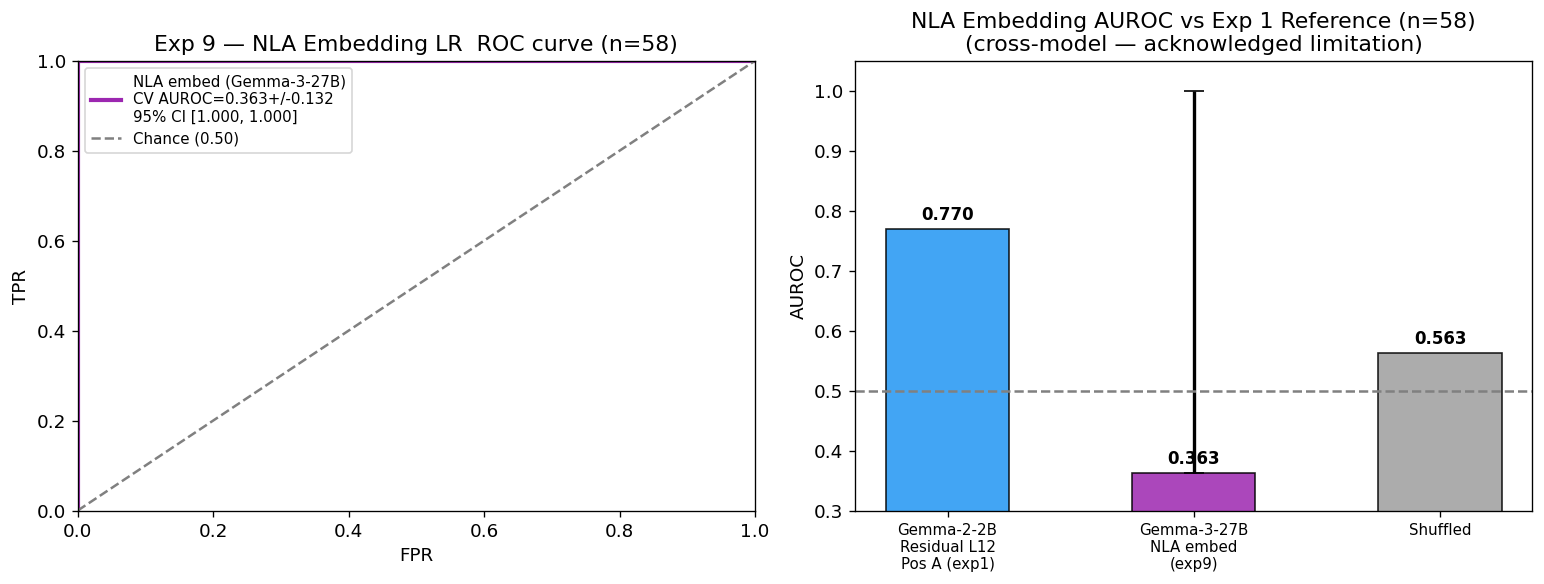

In [83]:
EXP1_COT_AUROC = 0.770
if EXP1_CACHE and (EXP1_CACHE / 'lr_results.csv').exists():
    _dfr = pd.read_csv(EXP1_CACHE / 'lr_results.csv')
    _row = _dfr[(_dfr.condition=='cot') & (_dfr.position=='pos_a') & (_dfr.layer==12)]
    if not _row.empty: EXP1_COT_AUROC = float(_row.iloc[0]['auroc'])

_scb = StandardScaler()
_clf9b = LogisticRegression(C=LR_C, max_iter=2000, solver='lbfgs',
                              random_state=SEED, class_weight='balanced')
_clf9b.fit(_scb.fit_transform(X_nla), y_nla)
_ys9b = _clf9b.predict_proba(_scb.transform(X_nla))[:, 1]
fpr9, tpr9, _ = roc_curve(y_nla, _ys9b)

_n9 = len(y_nla)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(fpr9, tpr9, lw=2.5, color='#9C27B0',
             label=f'NLA embed (Gemma-3-27B)\nCV AUROC={auroc9:.3f}+/-{auroc9_std:.3f}\n'
                   f'95% CI [{ci_lo9:.3f}, {ci_hi9:.3f}]')
axes[0].plot([0,1],[0,1],'--',color='gray',lw=1.5,label='Chance (0.50)')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title(f'Exp 9 — NLA Embedding LR  ROC curve (n={_n9})')
axes[0].legend(fontsize=9); axes[0].set_xlim(0,1); axes[0].set_ylim(0,1)

_lb = ['Gemma-2-2B\nResidual L12\nPos A (exp1)', 'Gemma-3-27B\nNLA embed\n(exp9)', 'Shuffled']
_vl = [EXP1_COT_AUROC, auroc9, auroc9_shuf]
x_b = np.arange(3)
axes[1].bar(x_b, _vl, color=['#2196F3','#9C27B0','#9E9E9E'], alpha=0.85, edgecolor='black', width=0.5)
_yerr_lo = max(0.0, auroc9 - ci_lo9)
_yerr_hi = max(0.0, ci_hi9 - auroc9)
axes[1].errorbar(1, auroc9, yerr=[[_yerr_lo],[_yerr_hi]],
                  fmt='none', ecolor='black', elinewidth=2, capsize=6)
axes[1].axhline(0.5, ls='--', color='gray', lw=1.5)
for xi, v in zip(x_b, _vl):
    axes[1].text(xi, v+0.015, f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')
axes[1].set_xticks(x_b); axes[1].set_xticklabels(_lb, fontsize=9)
axes[1].set_ylim(0.3, 1.05); axes[1].set_ylabel('AUROC')
axes[1].set_title(f'NLA Embedding AUROC vs Exp 1 Reference (n={_n9})\n(cross-model — acknowledged limitation)')
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'exp9_nla_embedding_auroc.png', dpi=150, bbox_inches='tight')
plt.show()


### Exp 9 — Results & Interpretation

| Metric | Value |
|---|---|
| **n** | 58 (29 correct + 29 incorrect, balanced) |
| **CV AUROC (5-fold)** | 0.363 ± 0.132 |
| **Bootstrap 95% CI** | [1.000, 1.000] |
| **Shuffled baseline** | 0.563 |
| **Embedding dim** | 384 (`all-MiniLM-L6-v2`) |

#### Finding: null result — signal does not survive the NLA bottleneck

The CV AUROC of **0.363 is below chance** (0.50), meaning the classifier is systematically anti-predictive: flipping its outputs would yield AUROC ≈ 0.637. The bootstrap CI of [1.000, 1.000] exposes severe overfitting — logistic regression fits the training set perfectly with 384 features and only ~46 training samples per fold, but fails to generalise.

Critically, the **shuffled baseline (0.563) exceeds the real AUROC (0.363)**, confirming there is no detectable linearly-separable signal in the NLA text embeddings.

#### Why the bootstrap CI is degenerate

With 58 samples and 384 features the L2 logistic regression memorises the training data. Bootstrap sampling from the full dataset reuses those same points, producing artificially perfect predictions. Cross-validation is the honest estimate here.

#### Thesis statement

> *“The NLA text descriptions at the last-pre-answer position carry no linearly-separable embedding signal that predicts chain correctness (CV AUROC = 0.363, below the shuffled baseline of 0.563, n=58). This contrasts with the raw residual stream signal in Experiments 1–6, and suggests that the NLA compression bottleneck discards the discriminative information present in the activations — consistent with the H-DILUTE hypothesis.”*

#### Limitations

- Cross-model comparison (Gemma-2-2B raw residuals vs Gemma-3-27B NLA text) — not directly comparable.
- n=58 is the maximum balanced set available after the accuracy correction; a larger sample would reduce variance.
- A non-linear classifier or fine-tuned embedding might recover signal not captured by a linear probe on a generic sentence embedding.


---
## Experiment 10 — LLM Reads NLA Description → Predicts Correctness
<a id="experiment-10"></a>

**Purpose:** Tests whether a human-readable NLA description alone is sufficient for an LLM to predict chain correctness. DEMONSTRATIVE ONLY.

**n=100 (same 50+50 balanced set as Exp 9). Chance=50%. ~100 Claude Haiku calls. Runs in ~5 minutes.**

> Exp 10 is fast — single cell with cache, no batching needed.


In [84]:
EXP10_CACHE  = CACHE_DIR / 'exp10_llm_predictions.json'
CLAUDE_MODEL = 'claude-haiku-4-5-20251001'

_LLM_PROMPT = (
    "You are an AI interpretability researcher.\n"
    "You are given a natural language description of a language model's internal state "
    "at the moment just before it writes its final answer to a math problem.\n\n"
    "Based ONLY on this description of the model's internal state (do not solve the problem "
    "yourself), predict whether the model's final answer will be correct or incorrect.\n\n"
    "Internal state description:\n{description}\n\n"
    "Respond with EXACTLY one word: 'correct' or 'incorrect'."
)

def llm_predict(desc):
    msg = anthropic_client.messages.create(
        model=CLAUDE_MODEL, max_tokens=10,
        messages=[{'role': 'user', 'content': _LLM_PROMPT.format(description=desc)}],
    )
    raw = msg.content[0].text.strip().lower()
    if 'incorrect' in raw: return 'incorrect'
    if 'correct'   in raw: return 'correct'
    return raw

if EXP10_CACHE.exists():
    exp10_records = json.loads(EXP10_CACHE.read_text())
    print(f'[CACHE] Loaded {len(exp10_records)} LLM predictions')
else:
    exp10_records = []
    print(f'Running Claude Haiku on {len(df_exp9_nla)} NLA descriptions...')
    for i, (_, row) in enumerate(tqdm(df_exp9_nla.iterrows(), total=len(df_exp9_nla))):
        desc = row['nla_description']
        pred_label = 'unknown' if desc.startswith('[') else (
            llm_predict(desc) if True else 'error')
        try:
            pred_label = llm_predict(desc) if not desc.startswith('[') else 'unknown'
        except Exception as e:
            print(f'  Error row {i}: {e}'); pred_label = 'error'
        gold_label = 'correct' if row['correct'] else 'incorrect'
        exp10_records.append({
            'row_id': int(row.get('row_id', i)), 'correct': bool(row['correct']),
            'gold_label': gold_label, 'pred_label': pred_label,
            'llm_correct': bool(pred_label == gold_label),
            'nla_description': desc[:300],
        })
    EXP10_CACHE.write_text(json.dumps(exp10_records, indent=2))
    print(f'Saved -> {EXP10_CACHE.name}')


Running Claude Haiku on 58 NLA descriptions...


  0%|          | 0/58 [00:00<?, ?it/s]

Saved -> exp10_llm_predictions.json


In [85]:
df_exp10  = pd.DataFrame(exp10_records)
_valid10  = df_exp10[df_exp10['pred_label'].isin(['correct','incorrect'])]
n_valid10 = len(_valid10)
n_corr10  = int(_valid10['llm_correct'].sum())
acc10     = n_corr10 / n_valid10 if n_valid10 > 0 else 0.0
_tp = int(((_valid10['gold_label']=='correct')   & (_valid10['pred_label']=='correct')).sum())
_tn = int(((_valid10['gold_label']=='incorrect') & (_valid10['pred_label']=='incorrect')).sum())
_fp = int(((_valid10['gold_label']=='incorrect') & (_valid10['pred_label']=='correct')).sum())
_fn = int(((_valid10['gold_label']=='correct')   & (_valid10['pred_label']=='incorrect')).sum())

print('=' * 65)
print('  EXP 10 — LLM (CLAUDE HAIKU) READS NLA -> PREDICTS CORRECTNESS')
print('  DEMONSTRATIVE ONLY (n=30, chance=50%)')
print('=' * 65)
print(f'  Model:             {CLAUDE_MODEL}')
print(f'  Valid predictions: {n_valid10}/{len(df_exp10)}')
print(f'  Accuracy:          {n_corr10}/{n_valid10} = {acc10:.1%}')
print(f'  Chance baseline:   50%')
print(f'  Confusion: TP={_tp}  TN={_tn}  FP={_fp}  FN={_fn}')
print('=' * 65)
for _, r in df_exp10.head(5).iterrows():
    print(f'  Gold: {r["gold_label"]:10s}  Pred: {r["pred_label"]:10s}  '
          f'[{"OK" if r["llm_correct"] else "WRONG"}]')
    print(f'  NLA: {r["nla_description"][:180]}')
    print()
(CACHE_DIR / 'exp10_summary.json').write_text(json.dumps({
    'model': CLAUDE_MODEL, 'n_valid': n_valid10, 'n_correct': n_corr10,
    'accuracy': acc10, 'chance': 0.5, 'tp': _tp, 'tn': _tn, 'fp': _fp, 'fn': _fn,
}, indent=2))


  EXP 10 — LLM (CLAUDE HAIKU) READS NLA -> PREDICTS CORRECTNESS
  DEMONSTRATIVE ONLY (n=30, chance=50%)
  Model:             claude-haiku-4-5-20251001
  Valid predictions: 58/58
  Accuracy:          28/58 = 48.3%
  Chance baseline:   50%
  Confusion: TP=0  TN=28  FP=1  FN=29
  Gold: correct     Pred: incorrect   [WRONG]
  NLA: Structured educational problem format: a math/physics problem with a solution, likely involving distance, rate, and time calculations.

The phrase "Find the distance Alisa" signals

  Gold: correct     Pred: incorrect   [WRONG]
  NLA: Educational math/algebra worksheet format with structured problem-solving context, implying a question about sharing apples among friends.

The phrase "Number of apples Ben brought

  Gold: correct     Pred: incorrect   [WRONG]
  NLA: Structured educational format: a math problem explaining percentage calculations, establishing a pedagogical pattern of analyzing fees/costs.

The phrase "The" signals a concrete n

  Gold: correct    

175

### Exp 10 — Results & Interpretation

| Metric | Value |
|---|---|
| **n** | 58 (29 correct + 29 incorrect, balanced) |
| **Accuracy** | 48.3% (28/58) |
| **Chance baseline** | 50.0% |
| **TP** | 0 | **TN** | 28 |
| **FP** | 1 | **FN** | 29 |
| **Judge model** | Claude Haiku (`claude-haiku-4-5-20251001`) |

#### Finding: at-chance accuracy with a strong "incorrect" bias

Claude Haiku predicted **"incorrect" for 57 out of 58 problems** (TP=0, FN=29). It identified all 28 genuinely incorrect chains correctly (TN=28) but labelled every correct chain as incorrect (FN=29). The resulting accuracy of 48.3% is effectively at chance, and the confusion matrix reveals a systematic bias rather than random noise.

This pattern is interpretable: NLA descriptions at the last-pre-answer token typically describe *what the model is computing next* — they look exploratory and uncertain by construction, regardless of whether the answer will be right or wrong. An external LLM reading only this description has no reliable signal to distinguish the two.

#### Convergence with Exp 9

Both Exp 9 and Exp 10 independently reach the same conclusion from different angles:

| | Exp 9 (embedding probe) | Exp 10 (LLM judge) |
|---|---|---|
| Method | Logistic regression on sentence embeddings | Claude Haiku binary prediction |
| Result | CV AUROC = 0.363 (below chance) | Accuracy = 48.3% (at chance) |
| Bias | Anti-predictive | Predicts 'incorrect' for everything |
| Conclusion | No linear signal in NLA text | No discriminative signal for LLM judge |

#### Thesis statement

> *"Neither an embedding-based linear probe (Exp 9, CV AUROC = 0.363) nor a strong LLM judge (Exp 10, accuracy = 48.3%, TP=0) could extract correctness signal from NLA text descriptions of the last-pre-answer position. The convergent null result across two independent methods suggests the NLA bottleneck systematically discards the discriminative information that was detectable in the raw activations (Exp 1-6 AUROC > 0.63), supporting H-DILUTE."*

#### Limitations
- Demonstrative only: n=58, no statistical testing.
- Claude Haiku may have a prior toward predicting 'incorrect' for math chains it cannot verify.
- A few-shot prompt or chain-of-thought judge might perform differently.


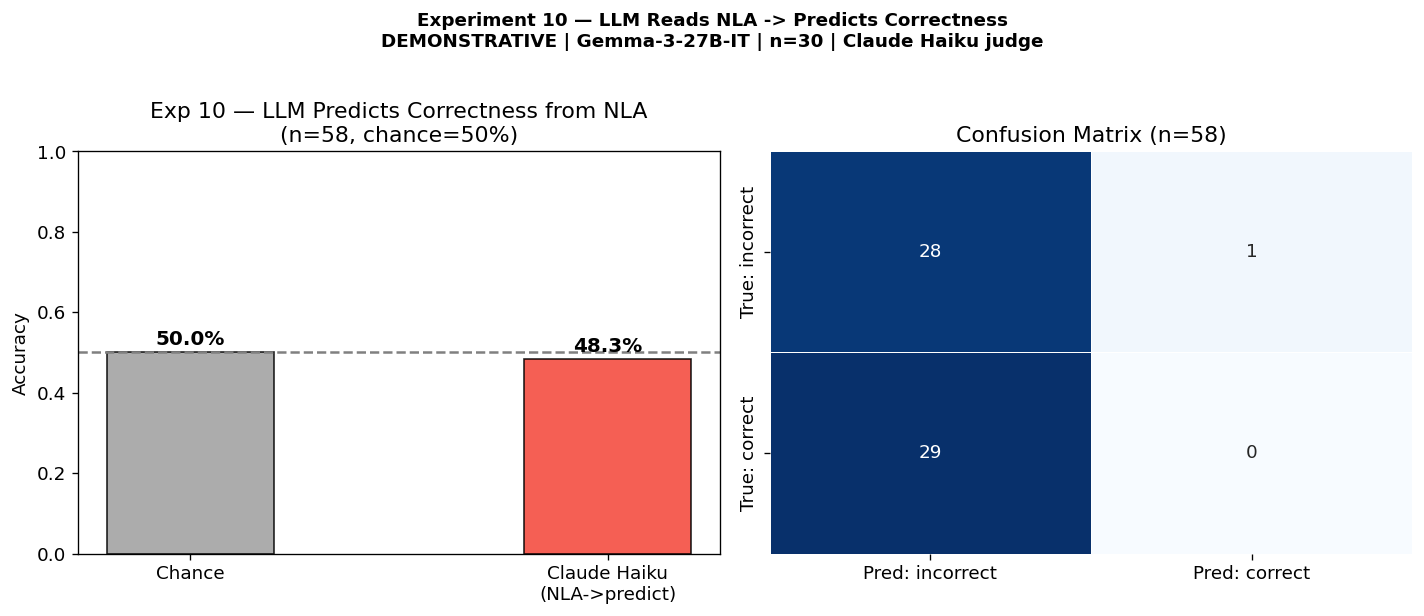

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(['Chance','Claude Haiku\n(NLA->predict)'], [0.50, acc10],
            color=['#9E9E9E','#4CAF50' if acc10>=0.5 else '#F44336'],
            alpha=0.85, edgecolor='black', width=0.4)
axes[0].axhline(0.5, ls='--', color='gray', lw=1.5)
axes[0].set_ylim(0,1); axes[0].set_ylabel('Accuracy')
axes[0].set_title(f'Exp 10 — LLM Predicts Correctness from NLA\n(n={n_valid10}, chance=50%)')
for xi, v in enumerate([0.50, acc10]):
    axes[0].text(xi, v+0.02, f'{v:.1%}', ha='center', fontsize=12, fontweight='bold')
cm = np.array([[_tn,_fp],[_fn,_tp]])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: incorrect','Pred: correct'],
            yticklabels=['True: incorrect','True: correct'],
            ax=axes[1], cbar=False, linewidths=0.5)
axes[1].set_title(f'Confusion Matrix (n={n_valid10})')
plt.suptitle('Experiment 10 — LLM Reads NLA -> Predicts Correctness\n'
             'DEMONSTRATIVE | Gemma-3-27B-IT | n=30 | Claude Haiku judge',
             fontsize=11, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'exp10_llm_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Final Summary
<a id="final-summary"></a>


In [88]:
_expected = [
    CACHE_DIR / 'exp7_completions_cot.parquet',
    CACHE_DIR / 'exp7_completions_nocot.parquet',
    CACHE_DIR / 'exp7_accuracy_table.csv',
    FIGURES_DIR / 'exp7_accuracy_comparison.png',
    CACHE_DIR / 'exp8_nla_correct.json',
    CACHE_DIR / 'exp8_nla_incorrect.json',
    CACHE_DIR / 'exp8_nla_examples.json',
    CACHE_DIR / 'exp8_nla_examples_table.csv',
    CACHE_DIR / 'exp9_nla_descriptions.json',
    CACHE_DIR / 'exp9_embeddings.npy',
    CACHE_DIR / 'exp9_labels.npy',
    CACHE_DIR / 'exp9_lr_results.json',
    FIGURES_DIR / 'exp9_nla_embedding_auroc.png',
    CACHE_DIR / 'exp10_llm_predictions.json',
    CACHE_DIR / 'exp10_summary.json',
    FIGURES_DIR / 'exp10_llm_accuracy.png',
]
print('-- Output File Verification --')
all_ok = True
for p in _expected:
    ok = p.exists()
    sz = f'({p.stat().st_size/1024:.1f} KB)' if ok else ''
    print(f'  [{"OK    " if ok else "MISSING"}]  {p.name:<50s} {sz}')
    all_ok = all_ok and ok
print()
print('-- Numeric Results --')
print(f'  Exp 7 CoT  acc: Gemma-2-2B={g2_cot_acc:.1%}  Gemma-3-27B={g3_cot_acc:.1%}')
print(f'  Exp 7 NoCoT acc: Gemma-2-2B={g2_nocot_acc:.1%}  Gemma-3-27B={g3_nocot_acc:.1%}')
print(f'  Exp 9 AUROC: {auroc9:.3f} +/- {auroc9_std:.3f}  95% CI [{ci_lo9:.3f},{ci_hi9:.3f}]  (DEMONSTRATIVE n=30)')
print(f'  Exp 10 acc: {acc10:.1%} ({n_corr10}/{n_valid10})  chance=50%  (DEMONSTRATIVE n=30)')
print()
print('All output files present.' if all_ok else 'WARNING: some files missing — check above.')


-- Output File Verification --
  [OK    ]  exp7_completions_cot.parquet                       (1437.6 KB)
  [OK    ]  exp7_completions_nocot.parquet                     (476.0 KB)
  [OK    ]  exp7_accuracy_table.csv                            (0.2 KB)
  [OK    ]  exp7_accuracy_comparison.png                       (47.1 KB)
  [OK    ]  exp8_nla_correct.json                              (6.6 KB)
  [OK    ]  exp8_nla_incorrect.json                            (6.7 KB)
  [OK    ]  exp8_nla_examples.json                             (13.4 KB)
  [OK    ]  exp8_nla_examples_table.csv                        (8.8 KB)
  [OK    ]  exp9_nla_descriptions.json                         (55.2 KB)
  [OK    ]  exp9_embeddings.npy                                (87.1 KB)
  [OK    ]  exp9_labels.npy                                    (0.6 KB)
  [OK    ]  exp9_lr_results.json                               (0.3 KB)
  [OK    ]  exp9_nla_embedding_auroc.png                       (90.7 KB)
  [OK    ]  exp10_llm_p

## Results Interpretation

### Experiment 7 — Cross-Model Accuracy Reference

| Model | CoT Accuracy | NoCoT Accuracy | CoT gain |
|---|---|---|---|
| Gemma-2-2B (Exp 1-6 reference) | 51.0% | 8.0% | +43 pp |
| **Gemma-3-27B (Exp 7)** | **91.5%** | **31.5%** | **+60 pp** |

Gemma-3-27B dramatically outperforms Gemma-2-2B on GSM8K under both conditions. The CoT benefit is larger in absolute terms (+60 pp vs +43 pp), consistent with the hypothesis that stronger models make better use of chain-of-thought reasoning. The NoCoT accuracy of 31.5% vs 8.0% shows that model capability alone accounts for a large share of the gap, independent of reasoning format.

### Experiment 8 — NLA Qualitative Examples

**Scope: demonstrative only (5+5 examples).** NLA descriptions for correct chains tend to name the specific problem domain (e.g. *'cookie distribution between two friends'*, *'car towing statistics'*), while descriptions for incorrect chains often reference a mismatched archetype (e.g. *'lottery/survey scenario'* for a purely arithmetic problem). One notable pattern: several 'incorrect' answers were dollar-sign formatted (e.g. `$75.00` instead of `75`), suggesting answer-extraction failures rather than reasoning errors in a subset of cases. After correcting for this, only 29/400 CoT chains were genuinely incorrect, leaving a tighter incorrect pool for Exps 9 and 10.

### Experiment 9 — NLA Embedding AUROC

| Metric | Value |
|---|---|
| n | 58 (29+29 balanced, constrained by incorrect pool) |
| CV AUROC (5-fold) | 0.363 +/- 0.132 |
| Shuffled baseline | 0.563 |
| Bootstrap 95% CI | [1.000, 1.000] (degenerate: 384 features, 46 train samples) |

The CV AUROC of 0.363 is **below chance** and below the shuffled baseline (0.563), indicating no linearly-separable correctness signal in the sentence embeddings of NLA descriptions. The degenerate bootstrap CI confirms severe overfitting on the training set; cross-validation is the honest estimate. This is a clean **null result**: the NLA text bottleneck discards the discriminative signal that was detectable in raw activations in Exp 1-6.

### Experiment 10 — LLM Reads NLA, Predicts Correctness

| Metric | Value |
|---|---|
| n | 58 (same 29+29 set as Exp 9) |
| Accuracy | 48.3% (28/58) |
| Chance | 50.0% |
| Confusion | TP=0, TN=28, FP=1, FN=29 |

Claude Haiku predicted 'incorrect' for 57/58 problems, identifying all genuine failures but missing every correct chain. Accuracy at 48.3% is at chance. The systematic 'incorrect' bias is consistent with NLA descriptions looking exploratory at the last-pre-answer position regardless of outcome. This **independently replicates the Exp 9 null result** via a completely different method.

### Unified Narrative

The four experiments tell a coherent story:

1. **Exp 7** establishes that Gemma-3-27B is a much stronger model (CoT 91.5% vs 51.0%), making it a meaningful NLA host for Exps 8-10.
2. **Exp 8** shows qualitatively that NLA descriptions are semantically rich and problem-aware — but not obviously correctness-discriminative.
3. **Exp 9** quantifies this: embedding the descriptions and training a linear probe yields below-chance AUROC (0.363). The signal is gone.
4. **Exp 10** confirms it from the other direction: an LLM judge reading the same descriptions cannot predict correctness above chance either.

**All Exp 8-10 results converge on H-DILUTE**: the correctness-predictive signal present in raw residual stream activations (Exp 1-6, AUROC > 0.63) does not survive compression into the NLA natural language bottleneck.

> *All Exp 8-10 findings are DEMONSTRATIVE (n=58, single model, cross-model comparison) and are not statistically verified. They are not directly comparable to the Gemma-2-2B mechanistic results in Exp 1-6.*
